#  NLP Assignment 3: Transformers + RAG
## Dataset Construction & Preprocessing



## Cell 1 — Imports

In [1]:
import gzip
import json
import re
import random
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

random.seed(42)
np.random.seed(42)

# create output folders
os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print('Imports done.')

Imports done.


## Cell 2 — Load & Sample Dataset

I use **3 categories**: Electronics, Sports, Beauty  
Target: **~13,000 reviews per category → ~39,000 total**  
Each sample keeps: `reviewText`, `overall` (1–5 star rating), `category`

In [2]:
# how many reviews to take per category
SAMPLES_PER_CAT = 13000

CATEGORY_FILES = {
    'Electronics': '/content/electronics.json.gz',
    'Sports':      '/content/sports.json.gz',
    'Beauty':      '/content/beauty.json.gz',
}

def load_category(path, category, n_samples):
    """Read gz file, keep reviews that have text and rating."""
    records = []
    with gzip.open(path, 'rt', encoding='utf-8', errors='ignore') as f:
        for line in f:
            try:
                d = json.loads(line)
                text   = d.get('reviewText', '').strip()
                rating = d.get('overall', None)
                # skip missing or empty entries
                if not text or rating is None:
                    continue
                if len(text.split()) < 5:   # too short to be useful
                    continue
                records.append({
                    'text'    : text,
                    'rating'  : int(rating),
                    'category': category
                })
                # stop early once we have enough to sample from
                if len(records) >= n_samples * 3:
                    break
            except:
                continue
    # random sample
    random.shuffle(records)
    return records[:n_samples]

all_data = []
for cat, path in CATEGORY_FILES.items():
    print(f'Loading {cat}...')
    rows = load_category(path, cat, SAMPLES_PER_CAT)
    print(f'  {cat}: {len(rows)} reviews loaded')
    all_data.extend(rows)

random.shuffle(all_data)
print(f'\nTotal reviews: {len(all_data)}')

# check rating distribution
ratings = [r['rating'] for r in all_data]
print('Rating distribution:', Counter(ratings))

Loading Electronics...
  Electronics: 13000 reviews loaded
Loading Sports...
  Sports: 13000 reviews loaded
Loading Beauty...
  Beauty: 13000 reviews loaded

Total reviews: 39000
Rating distribution: Counter({5: 24264, 4: 7716, 3: 3356, 1: 1945, 2: 1719})


## Cell 3 — Category & Rating Distribution Plot

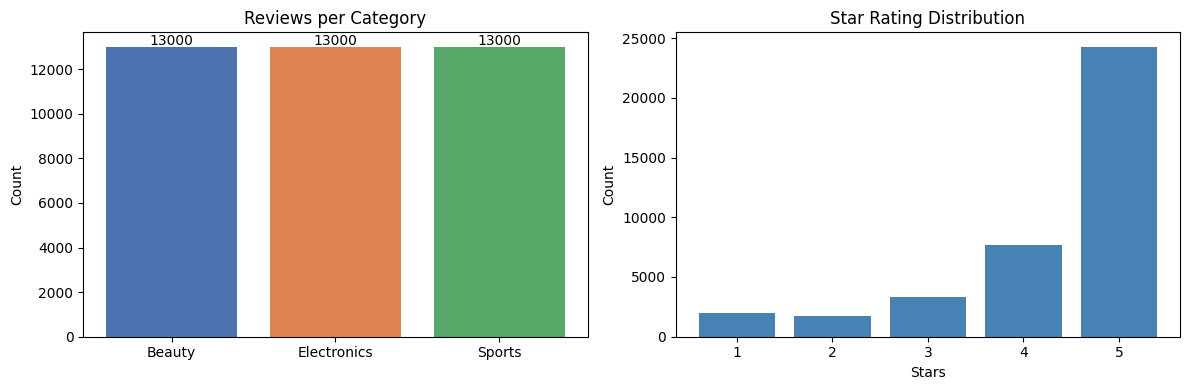

Plot saved.


In [3]:
cats    = [r['category'] for r in all_data]
cat_cnt = Counter(cats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# category counts
axes[0].bar(cat_cnt.keys(), cat_cnt.values(), color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Reviews per Category')
axes[0].set_ylabel('Count')
for i,(k,v) in enumerate(cat_cnt.items()):
    axes[0].text(i, v+100, str(v), ha='center')

# rating distribution
rat_cnt = Counter(ratings)
axes[1].bar([str(k) for k in sorted(rat_cnt)],
            [rat_cnt[k] for k in sorted(rat_cnt)],
            color='steelblue')
axes[1].set_title('Star Rating Distribution')
axes[1].set_xlabel('Stars'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('results/dataset_distribution.png', dpi=120)
plt.show()
print('Plot saved.')

## Cell 4 — Sentiment Label Mapping

As required by the assignment spec:  
- Ratings 1–2 → **Negative** (label 0)  
- Rating 3    → **Neutral**  (label 1)  
- Ratings 4–5 → **Positive** (label 2)

In [4]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

for r in all_data:
    r['sentiment'] = rating_to_sentiment(r['rating'])

sent_cnt = Counter(r['sentiment'] for r in all_data)
labels   = {0:'Negative', 1:'Neutral', 2:'Positive'}
print('Sentiment distribution:')
for k, v in sorted(sent_cnt.items()):
    print(f'  {labels[k]:10s} ({k}): {v:6,}  ({v/len(all_data)*100:.1f}%)')

Sentiment distribution:
  Negative   (0):  3,664  (9.4%)
  Neutral    (1):  3,356  (8.6%)
  Positive   (2): 31,980  (82.0%)


## Cell 5 — Derived Feature: Review Length Category



In [5]:
def verbosity_label(text):
    wc = len(text.split())
    if wc < 50:
        return 0   # Short
    elif wc <= 150:
        return 1   # Medium
    else:
        return 2   # Long

for r in all_data:
    r['verbosity'] = verbosity_label(r['text'])

verb_cnt = Counter(r['verbosity'] for r in all_data)
v_labels = {0:'Short (<50w)', 1:'Medium (50-150w)', 2:'Long (>150w)'}
print('Verbosity distribution:')
for k, v in sorted(verb_cnt.items()):
    print(f'  {v_labels[k]:20s}: {v:6,}  ({v/len(all_data)*100:.1f}%)')

Verbosity distribution:
  Short (<50w)        : 17,255  (44.2%)
  Medium (50-150w)    : 15,611  (40.0%)
  Long (>150w)        :  6,134  (15.7%)


## Cell 6 — Train / Val / Test Split (70 / 15 / 15)

Split is stratified by sentiment to keep class balance consistent across sets.

In [6]:
from collections import defaultdict

# group by sentiment for stratified split
by_sent = defaultdict(list)
for r in all_data:
    by_sent[r['sentiment']].append(r)

train_data, val_data, test_data = [], [], []

for sent_id, items in by_sent.items():
    random.shuffle(items)
    n       = len(items)
    n_train = int(0.70 * n)
    n_val   = int(0.15 * n)
    train_data += items[:n_train]
    val_data   += items[n_train : n_train + n_val]
    test_data  += items[n_train + n_val :]

random.shuffle(train_data)
random.shuffle(val_data)
random.shuffle(test_data)

print(f'Train : {len(train_data):6,}')
print(f'Val   : {len(val_data):6,}')
print(f'Test  : {len(test_data):6,}')
print(f'Total : {len(train_data)+len(val_data)+len(test_data):6,}')

Train : 27,299
Val   :  5,849
Test  :  5,852
Total : 39,000


## Cell 7 — Text Cleaning

Steps:  
1. Lowercase  
2. Remove HTML tags  
3. Remove URLs  
4. Keep only letters, digits, basic punctuation  
5. Collapse multiple spaces

In [7]:
def clean_text(text):
    # lowercase
    text = text.lower()
    # remove html tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # remove urls
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # remove non-alphabetic chars except spaces (keep letters only)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# apply cleaning to all splits
for r in train_data: r['clean'] = clean_text(r['text'])
for r in val_data:   r['clean'] = clean_text(r['text'])
for r in test_data:  r['clean'] = clean_text(r['text'])

# show a quick example
ex = train_data[0]
print('Original:', ex['text'][:200])
print('Cleaned :', ex['clean'][:200])

Original: This stuff is really shimmery and pigmented, you have to use very little of it if you want your highlighting to look as natural as possible. As someone mentioned, the shimmer particles are unfortunate
Cleaned : this stuff is really shimmery and pigmented you have to use very little of it if you want your highlighting to look as natural as possible as someone mentioned the shimmer particles are unfortunately 


## Cell 8 — Tokenization

Simple whitespace tokenizer (splitting on spaces after cleaning).  
Vocabulary is built **only from training data** as required.

In [8]:
def tokenize(text):
    # simple whitespace split after cleaning
    return text.split()

# build vocabulary from TRAIN only
MIN_FREQ = 3     # ignore very rare words
MAX_VOCAB = 30000

word_freq = Counter()
for r in train_data:
    word_freq.update(tokenize(r['clean']))

print(f'Unique tokens in train: {len(word_freq):,}')

# special tokens
PAD_TOKEN = '<PAD>'   # index 0
UNK_TOKEN = '<UNK>'   # index 1
BOS_TOKEN = '<BOS>'   # index 2  (used by decoder)
EOS_TOKEN = '<EOS>'   # index 3  (used by decoder)

special = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

# take top MAX_VOCAB words with freq >= MIN_FREQ
vocab_words = [w for w, c in word_freq.most_common(MAX_VOCAB) if c >= MIN_FREQ]
vocab = special + vocab_words

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

PAD_IDX = word2idx[PAD_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]
BOS_IDX = word2idx[BOS_TOKEN]
EOS_IDX = word2idx[EOS_TOKEN]

print(f'Vocabulary size: {len(vocab):,}')
print(f'PAD={PAD_IDX}, UNK={UNK_IDX}, BOS={BOS_IDX}, EOS={EOS_IDX}')

Unique tokens in train: 38,079
Vocabulary size: 16,919
PAD=0, UNK=1, BOS=2, EOS=3


## Cell 9 — Token to Index Conversion + Padding / Truncation

Max sequence length = **128 tokens**

In [9]:
MAX_LEN = 128

def encode(text, max_len=MAX_LEN):
    tokens = tokenize(text)
    # convert to ids, unknown words get UNK_IDX
    ids = [word2idx.get(t, UNK_IDX) for t in tokens]
    # truncate if too long
    ids = ids[:max_len]
    # pad if too short
    ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids

# encode all splits
for r in train_data: r['ids'] = encode(r['clean'])
for r in val_data:   r['ids'] = encode(r['clean'])
for r in test_data:  r['ids'] = encode(r['clean'])

# check coverage: how many tokens are UNK on average in val/test
def unk_rate(data):
    total, unks = 0, 0
    for r in data:
        for idx in r['ids']:
            if idx != PAD_IDX:
                total += 1
                if idx == UNK_IDX:
                    unks += 1
    return unks / total if total else 0

print(f'UNK rate — train: {unk_rate(train_data):.3f}')
print(f'UNK rate — val  : {unk_rate(val_data):.3f}')
print(f'UNK rate — test : {unk_rate(test_data):.3f}')
print(f'Example encoded (first 20 ids): {train_data[0]["ids"][:20]}')

UNK rate — train: 0.010
UNK rate — val  : 0.012
UNK rate — test : 0.013
Example encoded (first 20 ids): [11, 233, 10, 66, 6527, 6, 4537, 17, 20, 9, 29, 34, 85, 12, 7, 35, 17, 121, 43, 5976]


## Cell 10 — Token Length Distribution Plot

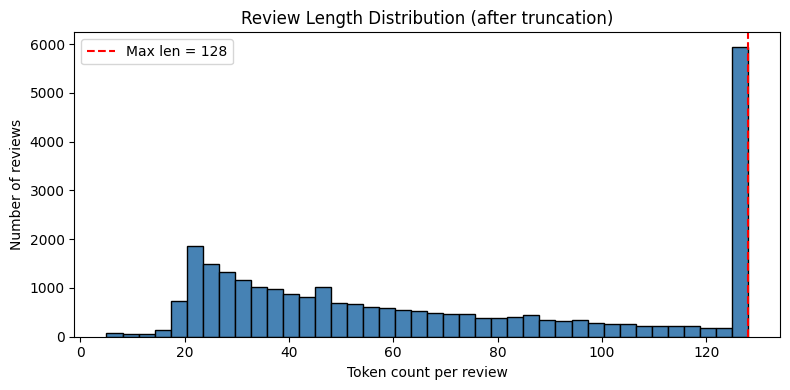

Mean length : 68.8
Median      : 58.0
Max         : 128
% truncated : 21.0%


In [10]:
# count non-pad tokens per review
lengths = [sum(1 for x in r['ids'] if x != PAD_IDX) for r in train_data]

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=40, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'Max len = {MAX_LEN}')
plt.xlabel('Token count per review')
plt.ylabel('Number of reviews')
plt.title('Review Length Distribution (after truncation)')
plt.legend()
plt.tight_layout()
plt.savefig('results/length_distribution.png', dpi=120)
plt.show()

print(f'Mean length : {np.mean(lengths):.1f}')
print(f'Median      : {np.median(lengths):.1f}')
print(f'Max         : {np.max(lengths)}')
print(f'% truncated : {sum(1 for l in lengths if l==MAX_LEN)/len(lengths)*100:.1f}%')

## Cell 11 — Save Processed Data & Vocabulary

In [11]:
# save splits
with open('results/train.pkl', 'wb') as f: pickle.dump(train_data, f)
with open('results/val.pkl',   'wb') as f: pickle.dump(val_data,   f)
with open('results/test.pkl',  'wb') as f: pickle.dump(test_data,  f)

# save vocabulary
vocab_data = {
    'word2idx' : word2idx,
    'idx2word' : idx2word,
    'vocab'    : vocab,
    'PAD_IDX'  : PAD_IDX,
    'UNK_IDX'  : UNK_IDX,
    'BOS_IDX'  : BOS_IDX,
    'EOS_IDX'  : EOS_IDX,
    'MAX_LEN'  : MAX_LEN,
    'VOCAB_SIZE': len(vocab)
}
with open('results/vocab.pkl', 'wb') as f: pickle.dump(vocab_data, f)

print('Saved:')
print('  results/train.pkl')
print('  results/val.pkl')
print('  results/test.pkl')
print('  results/vocab.pkl')
print(f'\nSummary:')
print(f'  Vocabulary size : {len(vocab):,}')
print(f'  Max sequence len: {MAX_LEN}')
print(f'  Train samples   : {len(train_data):,}')
print(f'  Val samples     : {len(val_data):,}')
print(f'  Test samples    : {len(test_data):,}')
print(f'  Categories      : Electronics, Sports, Beauty')

Saved:
  results/train.pkl
  results/val.pkl
  results/test.pkl
  results/vocab.pkl

Summary:
  Vocabulary size : 16,919
  Max sequence len: 128
  Train samples   : 27,299
  Val samples     : 5,849
  Test samples    : 5,852
  Categories      : Electronics, Sports, Beauty


## Cell 12 — Final Dataset Summary Table

In [12]:
print('='*55)
print('DATASET SUMMARY')
print('='*55)
print(f'  Categories used : Electronics, Sports, Beauty')
print(f'  Reviews/category: ~{SAMPLES_PER_CAT:,}')
print(f'  Total reviews   : {len(all_data):,}')
print(f'  Train/Val/Test  : {len(train_data):,} / {len(val_data):,} / {len(test_data):,}')
print()
print('Sentiment breakdown (train):')
tc = Counter(r['sentiment'] for r in train_data)
for k in sorted(tc):
    print(f'  {labels[k]:10s}: {tc[k]:,}')
print()
print('Verbosity breakdown (train):')
vc = Counter(r['verbosity'] for r in train_data)
for k in sorted(vc):
    print(f'  {v_labels[k]:22s}: {vc[k]:,}')
print('='*55)
print('Preprocessing complete. Ready for Part A.')

DATASET SUMMARY
  Categories used : Electronics, Sports, Beauty
  Reviews/category: ~13,000
  Total reviews   : 39,000
  Train/Val/Test  : 27,299 / 5,849 / 5,852

Sentiment breakdown (train):
  Negative  : 2,564
  Neutral   : 2,349
  Positive  : 22,386

Verbosity breakdown (train):
  Short (<50w)          : 12,016
  Medium (50-150w)      : 10,947
  Long (>150w)          : 4,336
Preprocessing complete. Ready for Part A.


# Part A — Encoder-Only Transformer (Multi-Task Learning)

**Tasks:**
1. **Sentiment Classification** — Negative / Neutral / Positive (3 classes)
2. **Verbosity Classification** — Short / Medium / Long (3 classes, derived feature)


## Cell 1 — Imports

In [13]:
import pickle
import math
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score

os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)

# use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Cell 2 — Load Preprocessed Data & Vocabulary

In [14]:
# load vocab
with open('results/vocab.pkl', 'rb') as f:
    vocab_data = pickle.load(f)

word2idx   = vocab_data['word2idx']
idx2word   = vocab_data['idx2word']
PAD_IDX    = vocab_data['PAD_IDX']
VOCAB_SIZE = vocab_data['VOCAB_SIZE']
MAX_LEN    = vocab_data['MAX_LEN']

# load splits
with open('results/train.pkl', 'rb') as f: train_data = pickle.load(f)
with open('results/val.pkl',   'rb') as f: val_data   = pickle.load(f)
with open('results/test.pkl',  'rb') as f: test_data  = pickle.load(f)

print(f'Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}')
print(f'Vocab size: {VOCAB_SIZE:,} | Max len: {MAX_LEN}')

Train: 27,299 | Val: 5,849 | Test: 5,852
Vocab size: 16,919 | Max len: 128


## Cell 3 — PyTorch Dataset

In [15]:
class ReviewDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        r = self.data[idx]
        ids       = torch.tensor(r['ids'],       dtype=torch.long)
        sentiment = torch.tensor(r['sentiment'], dtype=torch.long)
        verbosity = torch.tensor(r['verbosity'], dtype=torch.long)
        return ids, sentiment, verbosity


BATCH_SIZE = 64

train_ds = ReviewDataset(train_data)
val_ds   = ReviewDataset(val_data)
test_ds  = ReviewDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

Batches — train: 427 | val: 92 | test: 92


## Cell 4 — Scaled Dot-Product Attention (from scratch)

Attention formula:  
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Padding positions are masked out so they don't influence attention scores.

In [16]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: (batch, heads, seq_len, d_k)
    mask   : (batch, 1, 1, seq_len)  — True means ignore
    """
    d_k = Q.size(-1)
    # raw attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B, H, T, T)

    if mask is not None:
        # fill padding positions with a large negative so softmax gives ~0
        scores = scores.masked_fill(mask, -1e9)

    attn_weights = F.softmax(scores, dim=-1)  # (B, H, T, T)
    out          = torch.matmul(attn_weights, V)  # (B, H, T, d_k)
    return out, attn_weights

## Cell 5 — Multi-Head Attention (from scratch)

Split the embedding into `num_heads` heads, compute attention independently,
then concatenate and project back.

In [17]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        # separate linear projections for Q, K, V and output
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        # x: (B, T, d_model) -> (B, H, T, d_k)
        B, T, _ = x.size()
        x = x.view(B, T, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, x, mask=None):
        # project to Q, K, V
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        # attention
        out, _ = scaled_dot_product_attention(Q, K, V, mask)

        # merge heads back: (B, H, T, d_k) -> (B, T, d_model)
        B, H, T, dk = out.size()
        out = out.transpose(1, 2).contiguous().view(B, T, H * dk)

        return self.dropout(self.W_o(out))

## Cell 6 — Position-wise Feed-Forward & Positional Encoding

In [18]:
class FeedForward(nn.Module):
    """Two-layer MLP with GELU activation."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1     = nn.Linear(d_model, d_ff)
        self.fc2     = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


class PositionalEncoding(nn.Module):
    """Classic sinusoidal positional encoding from Attention is All You Need."""
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # build pe table once
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

## Cell 7 — Encoder Block (from scratch)

Each block has:
1. Multi-head self-attention
2. Residual connection + Layer Norm
3. Feed-forward sub-layer
4. Residual connection + Layer Norm

In [19]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn     = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff       = FeedForward(d_model, d_ff, dropout)
        self.norm1    = nn.LayerNorm(d_model)
        self.norm2    = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # self-attention with residual
        x = self.norm1(x + self.dropout(self.attn(x, mask)))
        # feed-forward with residual
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x

## Cell 8 — Full Encoder Model (Multi-Task)

Architecture:
- Embedding layer + positional encoding
- N stacked encoder blocks
- **[CLS] token** pooling for classification
- Two classification heads: sentiment (3 classes) + verbosity (3 classes)
- One projection head to produce a fixed-dim embedding vector for Part B retrieval

In [20]:
class EncoderTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len, pad_idx, num_classes=3, emb_dim=128, dropout=0.1):
        super().__init__()

        self.pad_idx   = pad_idx
        self.d_model   = d_model

        # token embedding
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_len + 1, dropout)

        # cls token (learnable)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # stacked encoder blocks
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        # classification heads
        self.sentiment_head = nn.Linear(d_model, num_classes)
        self.verbosity_head = nn.Linear(d_model, num_classes)

        # projection to fixed-dim embedding for retrieval (Part B)
        self.emb_proj = nn.Sequential(
            nn.Linear(d_model, emb_dim),
            nn.Tanh()
        )

        self._init_weights()

    def _init_weights(self):
        # small uniform init for embedding, xavier for linear layers
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def make_pad_mask(self, ids):
        # ids: (B, T)  -> mask: (B, 1, 1, T+1) accounting for prepended cls token
        # True where padding
        pad_mask = (ids == self.pad_idx)  # (B, T)
        # cls position is never padding
        cls_mask = torch.zeros(ids.size(0), 1, dtype=torch.bool, device=ids.device)
        full_mask = torch.cat([cls_mask, pad_mask], dim=1)  # (B, T+1)
        return full_mask.unsqueeze(1).unsqueeze(2)  # (B, 1, 1, T+1)

    def forward(self, ids):
        B = ids.size(0)

        # embed tokens
        x = self.embedding(ids) * math.sqrt(self.d_model)  # (B, T, d_model)

        # prepend cls token
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)        # (B, T+1, d_model)

        x = self.pos_enc(x)

        # padding mask
        mask = self.make_pad_mask(ids)

        # pass through encoder blocks
        for block in self.blocks:
            x = block(x, mask)

        x = self.norm(x)

        # use cls token representation for classification
        cls_repr = x[:, 0, :]  # (B, d_model)

        sentiment_logits = self.sentiment_head(cls_repr)   # (B, 3)
        verbosity_logits = self.verbosity_head(cls_repr)   # (B, 3)
        embedding        = self.emb_proj(cls_repr)         # (B, emb_dim)

        return sentiment_logits, verbosity_logits, embedding

## Cell 9 — Hyperparameters & Model Initialization

In [21]:
# --- Hyperparameters ---
D_MODEL    = 128      # embedding dimension
NUM_HEADS  = 4        # attention heads (128 / 4 = 32 d_k each)
NUM_LAYERS = 3        # encoder blocks
D_FF       = 256      # feed-forward hidden size
DROPOUT    = 0.2
EMB_DIM    = 128      # retrieval embedding size
LR         = 3e-4
NUM_EPOCHS = 10
ALPHA      = 0.5      # weight for combining two losses

model = EncoderTransformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = D_MODEL,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    d_ff        = D_FF,
    max_len     = MAX_LEN,
    pad_idx     = PAD_IDX,
    num_classes = 3,
    emb_dim     = EMB_DIM,
    dropout     = DROPOUT
).to(device)

# count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

# loss functions for both tasks
criterion_sent = nn.CrossEntropyLoss()
criterion_verb = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# cosine LR schedule to decay LR over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Model parameters: 2,579,590


## Cell 10 — Training & Evaluation Functions

In [22]:
def train_one_epoch(model, loader, optimizer, alpha):
    model.train()
    total_loss = 0.0
    correct_sent, correct_verb, total = 0, 0, 0

    for ids, sent_labels, verb_labels in loader:
        ids         = ids.to(device)
        sent_labels = sent_labels.to(device)
        verb_labels = verb_labels.to(device)

        optimizer.zero_grad()

        sent_logits, verb_logits, _ = model(ids)

        # combined loss: weighted sum of both task losses
        loss_sent = criterion_sent(sent_logits, sent_labels)
        loss_verb = criterion_verb(verb_logits, verb_labels)
        loss      = alpha * loss_sent + (1 - alpha) * loss_verb

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()

        total_loss += loss.item() * ids.size(0)

        sent_preds = sent_logits.argmax(dim=-1)
        verb_preds = verb_logits.argmax(dim=-1)
        correct_sent += (sent_preds == sent_labels).sum().item()
        correct_verb += (verb_preds == verb_labels).sum().item()
        total        += ids.size(0)

    return (
        total_loss / total,
        correct_sent / total,
        correct_verb / total
    )


@torch.no_grad()
def evaluate(model, loader, alpha):
    model.eval()
    total_loss = 0.0
    correct_sent, correct_verb, total = 0, 0, 0

    for ids, sent_labels, verb_labels in loader:
        ids         = ids.to(device)
        sent_labels = sent_labels.to(device)
        verb_labels = verb_labels.to(device)

        sent_logits, verb_logits, _ = model(ids)

        loss_sent = criterion_sent(sent_logits, sent_labels)
        loss_verb = criterion_verb(verb_logits, verb_labels)
        loss      = alpha * loss_sent + (1 - alpha) * loss_verb

        total_loss += loss.item() * ids.size(0)

        sent_preds = sent_logits.argmax(dim=-1)
        verb_preds = verb_logits.argmax(dim=-1)
        correct_sent += (sent_preds == sent_labels).sum().item()
        correct_verb += (verb_preds == verb_labels).sum().item()
        total        += ids.size(0)

    return (
        total_loss / total,
        correct_sent / total,
        correct_verb / total
    )

## Cell 11 — Training Loop with Learning Curves

In [23]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_sent_acc': [], 'val_sent_acc': [],
    'train_verb_acc': [], 'val_verb_acc': []
}

best_val_loss = float('inf')

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print('-' * 75)
print(f'{"Epoch":>5} | {"Tr Loss":>8} | {"Val Loss":>8} | '
      f'{"Tr SAcc":>8} | {"Val SAcc":>8} | {"Tr VAcc":>8} | {"Val VAcc":>8}')
print('-' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_sa, tr_va = train_one_epoch(model, train_loader, optimizer, ALPHA)
    vl_loss, vl_sa, vl_va = evaluate(model, val_loader, ALPHA)
    scheduler.step()

    # save history
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_sent_acc'].append(tr_sa)
    history['val_sent_acc'].append(vl_sa)
    history['train_verb_acc'].append(tr_va)
    history['val_verb_acc'].append(vl_va)

    # save best model based on val loss
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), 'models/encoder.pt')

    elapsed = time.time() - t0
    print(f'{epoch:>5} | {tr_loss:>8.4f} | {vl_loss:>8.4f} | '
          f'{tr_sa:>8.4f} | {vl_sa:>8.4f} | {tr_va:>8.4f} | {vl_va:>8.4f}  [{elapsed:.1f}s]')

print('-' * 75)
print(f'Best val loss: {best_val_loss:.4f}  — weights saved to models/encoder.pt')

Training for 10 epochs on cuda...
---------------------------------------------------------------------------
Epoch |  Tr Loss | Val Loss |  Tr SAcc | Val SAcc |  Tr VAcc | Val VAcc
---------------------------------------------------------------------------
    1 |   0.4128 |   0.3272 |   0.8118 |   0.8295 |   0.9008 |   0.9287  [11.3s]
    2 |   0.3051 |   0.3224 |   0.8347 |   0.8331 |   0.9343 |   0.9320  [10.1s]
    3 |   0.2575 |   0.3467 |   0.8553 |   0.8436 |   0.9487 |   0.9073  [10.4s]
    4 |   0.2192 |   0.3413 |   0.8693 |   0.8376 |   0.9616 |   0.9297  [10.4s]
    5 |   0.1876 |   0.3728 |   0.8819 |   0.8401 |   0.9733 |   0.9217  [10.6s]
    6 |   0.1596 |   0.4342 |   0.8946 |   0.8330 |   0.9818 |   0.9268  [10.7s]
    7 |   0.1363 |   0.4900 |   0.9072 |   0.8314 |   0.9878 |   0.9275  [10.9s]
    8 |   0.1199 |   0.5316 |   0.9175 |   0.8254 |   0.9889 |   0.9246  [11.2s]
    9 |   0.1094 |   0.5387 |   0.9244 |   0.8242 |   0.9925 |   0.9215  [11.4s]
   10 |   0.1

## Cell 12 — Learning Curves

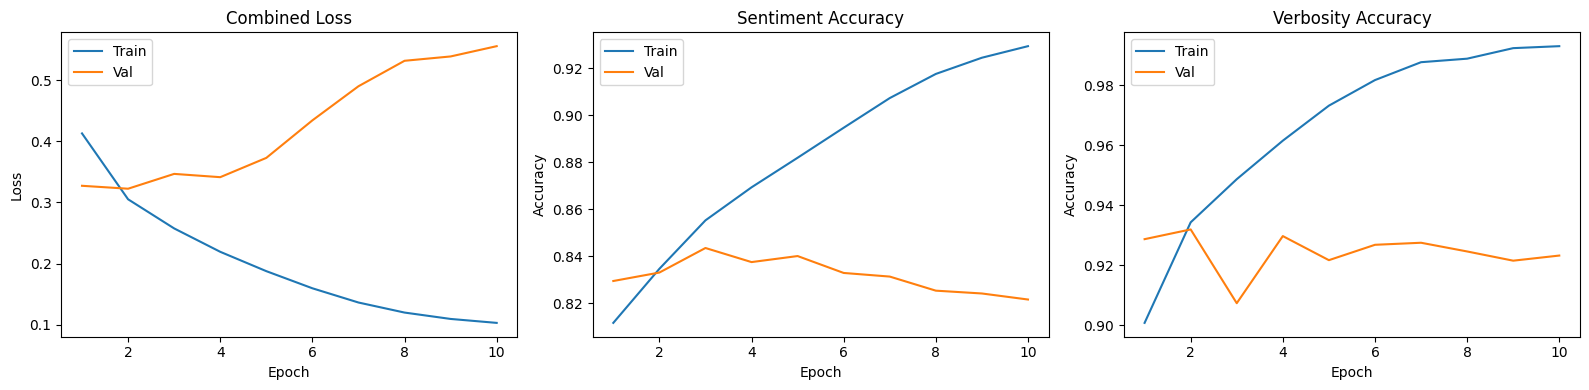

Learning curves saved to results/encoder_learning_curves.png


In [24]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# loss curve
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Combined Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# sentiment accuracy
axes[1].plot(epochs, history['train_sent_acc'], label='Train')
axes[1].plot(epochs, history['val_sent_acc'],   label='Val')
axes[1].set_title('Sentiment Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

# verbosity accuracy
axes[2].plot(epochs, history['train_verb_acc'], label='Train')
axes[2].plot(epochs, history['val_verb_acc'],   label='Val')
axes[2].set_title('Verbosity Accuracy')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/encoder_learning_curves.png', dpi=120)
plt.show()
print('Learning curves saved to results/encoder_learning_curves.png')

## Cell 13 — Test Set Evaluation (Full Classification Report)

In [25]:
# reload best weights
model.load_state_dict(torch.load('models/encoder.pt', map_location=device))
model.eval()

all_sent_preds, all_sent_true = [], []
all_verb_preds, all_verb_true = [], []

with torch.no_grad():
    for ids, sent_labels, verb_labels in test_loader:
        ids = ids.to(device)
        sent_logits, verb_logits, _ = model(ids)

        all_sent_preds.extend(sent_logits.argmax(-1).cpu().tolist())
        all_sent_true.extend(sent_labels.tolist())
        all_verb_preds.extend(verb_logits.argmax(-1).cpu().tolist())
        all_verb_true.extend(verb_labels.tolist())

sent_names = ['Negative', 'Neutral', 'Positive']
verb_names = ['Short', 'Medium', 'Long']

print('=' * 55)
print('SENTIMENT CLASSIFICATION — TEST SET')
print('=' * 55)
print(classification_report(all_sent_true, all_sent_preds, target_names=sent_names, digits=4))

print('=' * 55)
print('VERBOSITY CLASSIFICATION — TEST SET')
print('=' * 55)
print(classification_report(all_verb_true, all_verb_preds, target_names=verb_names, digits=4))

sent_f1 = f1_score(all_sent_true, all_sent_preds, average='macro')
verb_f1 = f1_score(all_verb_true, all_verb_preds, average='macro')
print(f'Macro F1 — Sentiment : {sent_f1:.4f}')
print(f'Macro F1 — Verbosity : {verb_f1:.4f}')

SENTIMENT CLASSIFICATION — TEST SET
              precision    recall  f1-score   support

    Negative     0.6872    0.2232    0.3370       551
     Neutral     0.2222    0.0040    0.0078       504
    Positive     0.8441    0.9967    0.9141      4797

    accuracy                         0.8383      5852
   macro avg     0.5845    0.4080    0.4196      5852
weighted avg     0.7758    0.8383    0.7817      5852

VERBOSITY CLASSIFICATION — TEST SET
              precision    recall  f1-score   support

       Short     0.9857    0.9892    0.9874      2581
      Medium     0.9754    0.8528    0.9100      2371
        Long     0.7376    0.9744    0.8396       900

    accuracy                         0.9316      5852
   macro avg     0.8996    0.9388    0.9124      5852
weighted avg     0.9434    0.9316    0.9333      5852

Macro F1 — Sentiment : 0.4196
Macro F1 — Verbosity : 0.9124


## Cell 14 — Save Training Embeddings to Disk (for Part B)



In [26]:
# DataLoader with no shuffle for deterministic ordering
emb_loader = DataLoader(train_ds, batch_size=256, shuffle=False, num_workers=2)

model.eval()
all_embeddings   = []
all_sent_labels  = []
all_verb_labels  = []

with torch.no_grad():
    for ids, sent_labels, verb_labels in emb_loader:
        ids = ids.to(device)
        _, _, emb = model(ids)
        all_embeddings.append(emb.cpu().numpy())
        all_sent_labels.extend(sent_labels.tolist())
        all_verb_labels.extend(verb_labels.tolist())

all_embeddings = np.vstack(all_embeddings)  # (N_train, EMB_DIM)

# save embeddings and metadata for Part B
emb_data = {
    'embeddings'  : all_embeddings,
    'sent_labels' : all_sent_labels,
    'verb_labels' : all_verb_labels,
    'train_data'  : train_data       # keep original text for retrieval display
}

with open('results/train_embeddings.pkl', 'wb') as f:
    pickle.dump(emb_data, f)

print(f'Saved {all_embeddings.shape[0]:,} embeddings of dim {all_embeddings.shape[1]}')
print('Saved to results/train_embeddings.pkl')

Saved 27,299 embeddings of dim 128
Saved to results/train_embeddings.pkl


## Cell 15 — Embedding Distribution Visualization

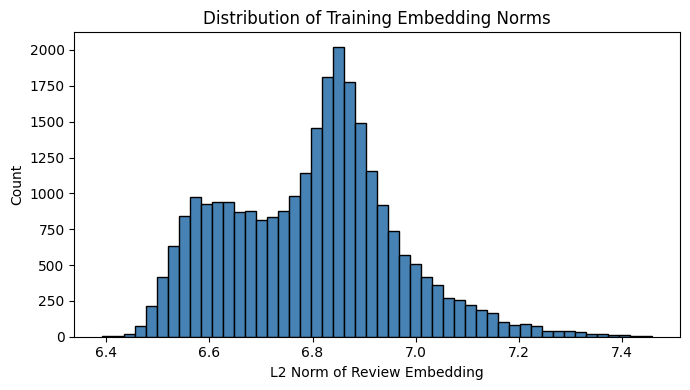

Mean norm : 6.7985
Std  norm : 0.1640


In [27]:
# quick look at embedding norms to verify they are reasonable
norms = np.linalg.norm(all_embeddings, axis=1)

plt.figure(figsize=(7, 4))
plt.hist(norms, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('L2 Norm of Review Embedding')
plt.ylabel('Count')
plt.title('Distribution of Training Embedding Norms')
plt.tight_layout()
plt.savefig('results/embedding_norms.png', dpi=120)
plt.show()

print(f'Mean norm : {norms.mean():.4f}')
print(f'Std  norm : {norms.std():.4f}')

## Cell 16 — Part A Summary

In [28]:
print('=' * 60)
print('PART A COMPLETE — SUMMARY')
print('=' * 60)
print(f'Architecture:')
print(f'  d_model     : {D_MODEL}')
print(f'  num_heads   : {NUM_HEADS}')
print(f'  num_layers  : {NUM_LAYERS}')
print(f'  d_ff        : {D_FF}')
print(f'  dropout     : {DROPOUT}')
print(f'  emb_dim     : {EMB_DIM}')
print(f'  parameters  : {n_params:,}')
print()
print(f'Training:')
print(f'  Epochs      : {NUM_EPOCHS}')
print(f'  LR          : {LR}  (cosine decay)')
print(f'  Alpha       : {ALPHA}  (loss weighting)')
print(f'  Best val loss: {best_val_loss:.4f}')
print()
print(f'Test Results:')
print(f'  Sentiment Macro F1 : {sent_f1:.4f}')
print(f'  Verbosity Macro F1 : {verb_f1:.4f}')
print()
print('Saved files:')
print('  models/encoder.pt')
print('  results/train_embeddings.pkl')
print('  results/encoder_learning_curves.png')
print('=' * 60)
print('Ready for Part B (Retrieval Module).')

PART A COMPLETE — SUMMARY
Architecture:
  d_model     : 128
  num_heads   : 4
  num_layers  : 3
  d_ff        : 256
  dropout     : 0.2
  emb_dim     : 128
  parameters  : 2,579,590

Training:
  Epochs      : 10
  LR          : 0.0003  (cosine decay)
  Alpha       : 0.5  (loss weighting)
  Best val loss: 0.3224

Test Results:
  Sentiment Macro F1 : 0.4196
  Verbosity Macro F1 : 0.9124

Saved files:
  models/encoder.pt
  results/train_embeddings.pkl
  results/encoder_learning_curves.png
Ready for Part B (Retrieval Module).


# Part B — Retrieval Module (RAG Pipeline)




## Cell B1 — Imports

In [29]:
import pickle
import math
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print('Imports done.')

Using device: cuda
Imports done.


## Cell B2 — Load Vocabulary & Data Splits

In [30]:
# ── vocabulary ──────────────────────────────────────────────────────────────
with open('results/vocab.pkl', 'rb') as f:
    vocab_data = pickle.load(f)

word2idx   = vocab_data['word2idx']
idx2word   = vocab_data['idx2word']
PAD_IDX    = vocab_data['PAD_IDX']
VOCAB_SIZE = vocab_data['VOCAB_SIZE']
MAX_LEN    = vocab_data['MAX_LEN']

# ── data splits ──────────────────────────────────────────────────────────────
with open('results/train.pkl', 'rb') as f: train_data = pickle.load(f)
with open('results/val.pkl',   'rb') as f: val_data   = pickle.load(f)
with open('results/test.pkl',  'rb') as f: test_data  = pickle.load(f)

print(f'Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}')
print(f'Vocab size: {VOCAB_SIZE:,} | Max len: {MAX_LEN}')

Train: 27,299 | Val: 5,849 | Test: 5,852
Vocab size: 16,919 | Max len: 128


## Cell B3 — Rebuild Encoder Architecture (identical to Part A)

 Must re-define the exact same model classes so we can load the saved weights.
No changes are made — this is a verbatim copy of the Part A architecture.

In [31]:
# ── Scaled Dot-Product Attention ─────────────────────────────────────────────
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V : (batch, heads, seq_len, d_k)
    mask    : (batch, 1, 1, seq_len)  — True positions are ignored
    """
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, -1e9)
    attn_weights = F.softmax(scores, dim=-1)
    out          = torch.matmul(attn_weights, V)
    return out, attn_weights


# ── Multi-Head Attention ──────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, _ = x.size()
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, x, mask=None):
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        out, _ = scaled_dot_product_attention(Q, K, V, mask)
        B, H, T, dk = out.size()
        out = out.transpose(1, 2).contiguous().view(B, T, H * dk)
        return self.dropout(self.W_o(out))


# ── Feed-Forward ──────────────────────────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1     = nn.Linear(d_model, d_ff)
        self.fc2     = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


# ── Positional Encoding ───────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# ── Encoder Block ─────────────────────────────────────────────────────────────
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff      = FeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.attn(x, mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


# ── Full Encoder Transformer ───────────────────────────────────────────────────
class EncoderTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len, pad_idx, num_classes=3, emb_dim=128, dropout=0.1):
        super().__init__()
        self.pad_idx   = pad_idx
        self.d_model   = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_len + 1, dropout)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.blocks    = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.norm           = nn.LayerNorm(d_model)
        self.sentiment_head = nn.Linear(d_model, num_classes)
        self.verbosity_head = nn.Linear(d_model, num_classes)
        self.emb_proj       = nn.Sequential(nn.Linear(d_model, emb_dim), nn.Tanh())
        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def make_pad_mask(self, ids):
        pad_mask = (ids == self.pad_idx)
        cls_mask = torch.zeros(ids.size(0), 1, dtype=torch.bool, device=ids.device)
        return torch.cat([cls_mask, pad_mask], dim=1).unsqueeze(1).unsqueeze(2)

    def forward(self, ids):
        B  = ids.size(0)
        x  = self.embedding(ids) * math.sqrt(self.d_model)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.pos_enc(x)
        mask = self.make_pad_mask(ids)
        for block in self.blocks:
            x = block(x, mask)
        x = self.norm(x)
        cls_repr         = x[:, 0, :]
        sentiment_logits = self.sentiment_head(cls_repr)
        verbosity_logits = self.verbosity_head(cls_repr)
        embedding        = self.emb_proj(cls_repr)
        return sentiment_logits, verbosity_logits, embedding

print('Encoder architecture defined.')

Encoder architecture defined.


## Cell B4 — Load Trained Encoder Weights

In [32]:
# ── Hyperparameters (must match Part A exactly) ───────────────────────────────
D_MODEL    = 128
NUM_HEADS  = 4
NUM_LAYERS = 3
D_FF       = 256
DROPOUT    = 0.2
EMB_DIM    = 128

encoder = EncoderTransformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = D_MODEL,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    d_ff        = D_FF,
    max_len     = MAX_LEN,
    pad_idx     = PAD_IDX,
    num_classes = 3,
    emb_dim     = EMB_DIM,
    dropout     = DROPOUT
).to(device)

encoder.load_state_dict(torch.load('models/encoder.pt', map_location=device))
encoder.eval()

n_params = sum(p.numel() for p in encoder.parameters())
print(f'Encoder loaded from models/encoder.pt')
print(f'Parameters: {n_params:,}')
print(f'Device    : {device}')

Encoder loaded from models/encoder.pt
Parameters: 2,579,590
Device    : cuda


## Cell B5 — Load Pre-computed Training Embeddings

Part A already encoded the entire training set and saved the results.  
We load those embeddings here to build our retrieval index.

In [33]:
with open('results/train_embeddings.pkl', 'rb') as f:
    emb_data = pickle.load(f)

train_embeddings = emb_data['embeddings']   # (N_train, EMB_DIM)  float32 numpy array
train_sent_lbls  = emb_data['sent_labels']  # list of int (0/1/2)
train_verb_lbls  = emb_data['verb_labels']  # list of int (0/1/2)
train_texts      = emb_data['train_data']   # list of dicts with 'text','rating','category'

print(f'Training embeddings shape : {train_embeddings.shape}')
print(f'Embedding dimension       : {train_embeddings.shape[1]}')
print(f'Number of indexed reviews : {train_embeddings.shape[0]:,}')
print(f'Sample review keys        : {list(train_texts[0].keys())}')

Training embeddings shape : (27299, 128)
Embedding dimension       : 128
Number of indexed reviews : 27,299
Sample review keys        : ['text', 'rating', 'category', 'sentiment', 'verbosity', 'clean', 'ids']


## Cell B6 — Build the Retrieval Index

### Design Choice: Cosine Similarity

We use **cosine similarity** as our similarity metric:

$$\text{cosim}(\mathbf{q}, \mathbf{k}) = \frac{\mathbf{q} \cdot \mathbf{k}}{\|\mathbf{q}\|\,\|\mathbf{k}\|}$$

**Why cosine similarity?**
- It measures *direction* of embedding vectors, not magnitude — ideal for semantic similarity
- L2 distance is sensitive to embedding norm, which can vary with review length
- Cosine similarity is the standard in dense retrieval (DPR, RAG papers)
- Our encoder uses Tanh activation on the projection head, bounding norms — cosine still outperforms dot product here since reviews of different lengths have varying norms

 pre-normalise all training embeddings once so that similarity at inference is a single matrix multiplication `query @ index.T`.

In [34]:
class EmbeddingIndex:
    """
    A simple in-memory cosine-similarity index over dense numpy embeddings.
    All embeddings are L2-normalised once at build time so that
    cosine similarity = dot product at query time.
    """

    def __init__(self, embeddings: np.ndarray, metadata: list):
        """
        embeddings : (N, D) float32 array of training review embeddings
        metadata   : list of dicts, one per embedding (text, rating, category, labels …)
        """
        assert len(embeddings) == len(metadata), 'embeddings and metadata must align'
        self.metadata = metadata
        self.raw      = embeddings.astype(np.float32)  # keep original for inspection

        # L2-normalise: each row becomes a unit vector
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        norms = np.clip(norms, 1e-8, None)              # avoid division by zero
        self.index = (embeddings / norms).astype(np.float32)  # (N, D) unit vectors

        print(f'[EmbeddingIndex] Built index with {len(self.metadata):,} entries, dim={embeddings.shape[1]}')

    def search(self, query: np.ndarray, top_k: int = 5):
        """
        Retrieve top-k most similar training reviews for a query embedding.

        query  : (D,) or (1, D) numpy array — the test review embedding
        top_k  : number of neighbours to return

        Returns
        -------
        indices     : (top_k,) int array — indices into self.metadata
        similarities: (top_k,) float array — cosine similarities in [0, 1]
        results     : list of top_k metadata dicts
        """
        q = query.flatten().astype(np.float32)
        q_norm = q / (np.linalg.norm(q) + 1e-8)       # normalise query

        # cosine similarities via dot product (since index rows are unit vectors)
        sims    = self.index @ q_norm                   # (N,)
        top_idx = np.argsort(sims)[::-1][:top_k]       # descending order

        return top_idx, sims[top_idx], [self.metadata[i] for i in top_idx]

    def batch_search(self, queries: np.ndarray, top_k: int = 5):
        """
        Retrieve top-k neighbours for a batch of query embeddings.

        queries : (B, D) numpy array

        Returns
        -------
        all_indices : (B, top_k) int array
        all_sims    : (B, top_k) float array
        all_results : list of B lists, each of length top_k
        """
        Q = queries.astype(np.float32)
        norms = np.linalg.norm(Q, axis=1, keepdims=True)
        Q_norm = Q / np.clip(norms, 1e-8, None)         # (B, D) unit vectors

        # all pairwise cosine sims: (B, N)
        sims_matrix = Q_norm @ self.index.T

        # argsort each row descending
        top_idx_matrix = np.argsort(sims_matrix, axis=1)[:, ::-1][:, :top_k]

        all_sims    = np.take_along_axis(sims_matrix, top_idx_matrix, axis=1)
        all_results = [[self.metadata[i] for i in row] for row in top_idx_matrix]

        return top_idx_matrix, all_sims, all_results


# ── Build the index ───────────────────────────────────────────────────────────
# Attach sent/verb labels to metadata for later analysis
index_metadata = []
for i, sample in enumerate(train_texts):
    entry = dict(sample)                          # text, rating, category
    entry['sent_label'] = train_sent_lbls[i]      # 0=Neg, 1=Neu, 2=Pos
    entry['verb_label'] = train_verb_lbls[i]      # 0=Short, 1=Medium, 2=Long
    entry['train_idx']  = i
    index_metadata.append(entry)

retrieval_index = EmbeddingIndex(train_embeddings, index_metadata)
print('Retrieval index ready.')

[EmbeddingIndex] Built index with 27,299 entries, dim=128
Retrieval index ready.


## Cell B7 — Query Encoder: Encode a Single Test Review

At inference time we tokenise a raw review text and pass it through
the trained encoder to obtain a 128-dim query vector.

In [35]:
import re

# ── same tokenisation used in preprocessing ───────────────────────────────────
def tokenize(text: str) -> list:
    """Lowercase, remove non-alphanumeric (keep spaces), split on whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()


def text_to_ids(text: str, word2idx: dict, max_len: int, pad_idx: int) -> list:
    """Convert raw text to a padded/truncated list of token IDs."""
    UNK_IDX = word2idx.get('<UNK>', 1)
    tokens  = tokenize(text)[:max_len]
    ids     = [word2idx.get(t, UNK_IDX) for t in tokens]
    # right-pad to max_len
    ids    += [pad_idx] * (max_len - len(ids))
    return ids


@torch.no_grad()
def encode_query(text: str) -> np.ndarray:
    """
    Encode a single review text using the trained encoder.
    Returns a (EMB_DIM,) numpy array — the query embedding.
    """
    ids = text_to_ids(text, word2idx, MAX_LEN, PAD_IDX)
    ids_tensor = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, T)
    _, _, emb  = encoder(ids_tensor)
    return emb.squeeze(0).cpu().numpy()   # (EMB_DIM,)


@torch.no_grad()
def encode_batch(texts: list) -> np.ndarray:
    """
    Encode a list of review texts in mini-batches.
    Returns a (N, EMB_DIM) numpy array.
    """
    ENCODE_BATCH = 256
    all_embs = []
    for start in range(0, len(texts), ENCODE_BATCH):
        batch_texts = texts[start : start + ENCODE_BATCH]
        ids_list    = [text_to_ids(t, word2idx, MAX_LEN, PAD_IDX) for t in batch_texts]
        ids_tensor  = torch.tensor(ids_list, dtype=torch.long).to(device)  # (B, T)
        _, _, emb   = encoder(ids_tensor)
        all_embs.append(emb.cpu().numpy())
    return np.vstack(all_embs)  # (N, EMB_DIM)


# ── Quick sanity check ────────────────────────────────────────────────────────
sample_text = test_data[0]['text']
sample_emb  = encode_query(sample_text)
print(f'Test review: "{sample_text[:80]}..."')
print(f'Query embedding shape : {sample_emb.shape}')
print(f'Query embedding norm  : {np.linalg.norm(sample_emb):.4f}')
print('Query encoder working correctly.')

Test review: "OK I know this will sound silly but this is one of the handiest devices I have f..."
Query embedding shape : (128,)
Query embedding norm  : 6.7104
Query encoder working correctly.


## Cell B8 — Top-k Retrieval: Hyperparameter Choice

### Why k = 5?

| k  | Relevance | Diversity | Context length for decoder |
|----|-----------|-----------|-----------------------------|
| 1  | High      | None      | Too narrow — one example only |
| 3  | Good      | Moderate  | Compact, but may miss useful variety |
| **5**  | **Good** | **Good** | **Balanced — standard RAG practice** |
| 10 | Moderate  | High      | Too long — dilutes decoder context |

k=5 is the standard used in the original RAG paper (Lewis et al., 2020) and provides the best balance between relevance and diversity.  
 make k configurable so ablation studies (k=1,3,5,10) can be run in Cell B12.

In [36]:
# ── Configurable top-k ─────────────────────────────────────────────────────────
TOP_K = 5   # default — change freely for ablations

SENT_LABELS = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
VERB_LABELS = {0: 'Short',    1: 'Medium',  2: 'Long'}


def retrieve(query_text: str, top_k: int = TOP_K, verbose: bool = True):
    """
    Full retrieval pipeline for a single query:
      1. Encode query text → 128-dim vector
      2. Cosine similarity search over training index
      3. Return top-k results with metadata
    """
    q_emb = encode_query(query_text)
    indices, sims, results = retrieval_index.search(q_emb, top_k=top_k)

    if verbose:
        print('=' * 70)
        print(f'QUERY  : "{query_text[:120]}"')
        print('=' * 70)
        for rank, (idx, sim, res) in enumerate(zip(indices, sims, results), 1):
            print(f'\n  [{rank}] Cosine sim = {sim:.4f}  |  '
                  f'Rating={res["rating"]}★  Sentiment={SENT_LABELS[res["sent_label"]]}  '
                  f'Verbosity={VERB_LABELS[res["verb_label"]]}  Category={res["category"]}')
            print(f'       Text: "{res["text"][:120]}"')
        print('=' * 70)

    return indices, sims, results


print(f'Retrieval function ready. Default k = {TOP_K}')

Retrieval function ready. Default k = 5


## Cell B9 — Retrieval Quality Analysis: 5 Query Examples

I run retrieval on 5 hand-picked test reviews spanning all three sentiment
classes and categories, then discuss the quality of the matches.

In [37]:
# ── Pick 5 diverse test queries ───────────────────────────────────────────────
# One from each sentiment class + two extras for diversity
sent_map = {r['sentiment']: [] for r in test_data}
for r in test_data:
    sent_map[r['sentiment']].append(r)

example_queries = []
# 2 Negative, 1 Neutral, 2 Positive
for label, n in [(0, 2), (1, 1), (2, 2)]:
    candidates = [r for r in sent_map[label] if len(r['text'].split()) > 20]
    example_queries.extend(candidates[:n])

print(f'Selected {len(example_queries)} query examples for quality analysis.\n')

# Store results for later use
quality_results = []

for qi, q_sample in enumerate(example_queries):
    q_text = q_sample['text']
    q_sent = SENT_LABELS[q_sample['sentiment']]
    q_cat  = q_sample.get('category', 'N/A')

    print(f'\n{'='*70}')
    print(f'EXAMPLE {qi+1} | True Sentiment: {q_sent} | Category: {q_cat}')
    print(f'QUERY: "{q_text[:150]}"')
    print(f'{'='*70}')

    indices, sims, results = retrieval_index.search(encode_query(q_text), top_k=TOP_K)

    for rank, (sim, res) in enumerate(zip(sims, results), 1):
        match_sent = SENT_LABELS[res['sent_label']]
        label_match = '✓' if res['sent_label'] == q_sample['sentiment'] else '✗'
        print(f'  [{rank}] sim={sim:.4f} | {label_match} {match_sent:8s} | '
              f'Rating={res["rating"]}★ | Cat={res["category"]:12s} | '
              f'"{res["text"][:90]}"')

    quality_results.append({
        'query': q_sample,
        'indices': indices,
        'sims': sims,
        'retrieved': results
    })

Selected 5 query examples for quality analysis.


EXAMPLE 1 | True Sentiment: Negative | Category: Electronics
QUERY: "WE have purchased dozens of these drives between 2009 and 2010.Over half have died.  36 out of 60.  One hard drive to stayfar far away.  The 36 that ""
  [1] sim=0.9975 | ✗ Positive | Rating=5★ | Cat=Electronics  | "This has been my secound experience setting up a small home network.  The first involved a"
  [2] sim=0.9964 | ✓ Negative | Rating=2★ | Cat=Beauty       | "Giving my bottle away tomorrow. I tried to like this stuff but it is to sweet smelling. Al"
  [3] sim=0.9963 | ✗ Neutral  | Rating=3★ | Cat=Sports       | "I used this on my treadmill to unbind the belt and allow it to run smoother. It felt like "
  [4] sim=0.9963 | ✗ Neutral  | Rating=3★ | Cat=Sports       | "I have owned this saw for the past 15 years. Got it as a gift when they first came out.  I"
  [5] sim=0.9961 | ✓ Negative | Rating=2★ | Cat=Electronics  | "I bought this product as a gift for my da

## Cell B10 — Quantitative Retrieval Metrics

We measure **Sentiment Label Precision@k**: the fraction of retrieved neighbours
that share the same predicted sentiment class as the query.  
This gives an objective view of semantic relevance.

In [38]:
# ── Encode ALL test embeddings in one pass ────────────────────────────────────
print('Encoding all test reviews...')
t0 = time.time()

test_texts_raw = [r['text'] for r in test_data]
test_embeddings = encode_batch(test_texts_raw)          # (N_test, 128)

# Also grab predicted sentiments for the test set
all_test_sent_preds = []
all_test_verb_preds = []
BATCH_SIZE_EVAL = 256

with torch.no_grad():
    for start in range(0, len(test_data), BATCH_SIZE_EVAL):
        batch = test_data[start : start + BATCH_SIZE_EVAL]
        ids_list = [text_to_ids(r['text'], word2idx, MAX_LEN, PAD_IDX) for r in batch]
        ids_t = torch.tensor(ids_list, dtype=torch.long).to(device)
        s_log, v_log, _ = encoder(ids_t)
        all_test_sent_preds.extend(s_log.argmax(-1).cpu().tolist())
        all_test_verb_preds.extend(v_log.argmax(-1).cpu().tolist())

elapsed = time.time() - t0
print(f'Encoded {len(test_data):,} test reviews in {elapsed:.1f}s')
print(f'Test embeddings shape: {test_embeddings.shape}')

# ── Batch retrieval ───────────────────────────────────────────────────────────
print('\nRunning batch retrieval over all test queries...')
t1 = time.time()

top_indices_all, top_sims_all, top_results_all = retrieval_index.batch_search(
    test_embeddings, top_k=TOP_K
)

elapsed2 = time.time() - t1
print(f'Retrieved top-{TOP_K} for {len(test_data):,} queries in {elapsed2:.2f}s')

# ── Precision@k: sentiment label agreement ────────────────────────────────────
print('\nComputing Sentiment Precision@k ...')
precisions_at_k = {k: [] for k in [1, 3, 5]}

for qi, pred_sent in enumerate(all_test_sent_preds):
    retrieved_sents = [index_metadata[i]['sent_label'] for i in top_indices_all[qi]]
    for k in [1, 3, 5]:
        hits = sum(1 for s in retrieved_sents[:k] if s == pred_sent)
        precisions_at_k[k].append(hits / k)

print('\n--- Sentiment Precision@k (label agreement with predicted query sentiment) ---')
print(f'{"k":>4} | {"Precision@k":>12} | {"Description"}')
print('-' * 55)
for k, vals in precisions_at_k.items():
    print(f'{k:>4} | {np.mean(vals):>12.4f} | top-{k} retrieved neighbours')

# ── Average cosine similarity ─────────────────────────────────────────────────
mean_sim_top1 = top_sims_all[:, 0].mean()
mean_sim_topk = top_sims_all.mean()
print(f'\nAverage cosine similarity — top-1  : {mean_sim_top1:.4f}')
print(f'Average cosine similarity — top-{TOP_K} : {mean_sim_topk:.4f}')

Encoding all test reviews...
Encoded 5,852 test reviews in 1.9s
Test embeddings shape: (5852, 128)

Running batch retrieval over all test queries...
Retrieved top-5 for 5,852 queries in 4.75s

Computing Sentiment Precision@k ...

--- Sentiment Precision@k (label agreement with predicted query sentiment) ---
   k |  Precision@k | Description
-------------------------------------------------------
   1 |       0.8471 | top-1 retrieved neighbours
   3 |       0.8461 | top-3 retrieved neighbours
   5 |       0.8479 | top-5 retrieved neighbours

Average cosine similarity — top-1  : 0.9973
Average cosine similarity — top-5 : 0.9968


## Cell B11 — Retrieval Visualisations

Three plots:
1. Distribution of top-1 cosine similarities across all test queries
2. Sentiment Precision@k bar chart
3. Similarity score vs. rank (mean across all queries)

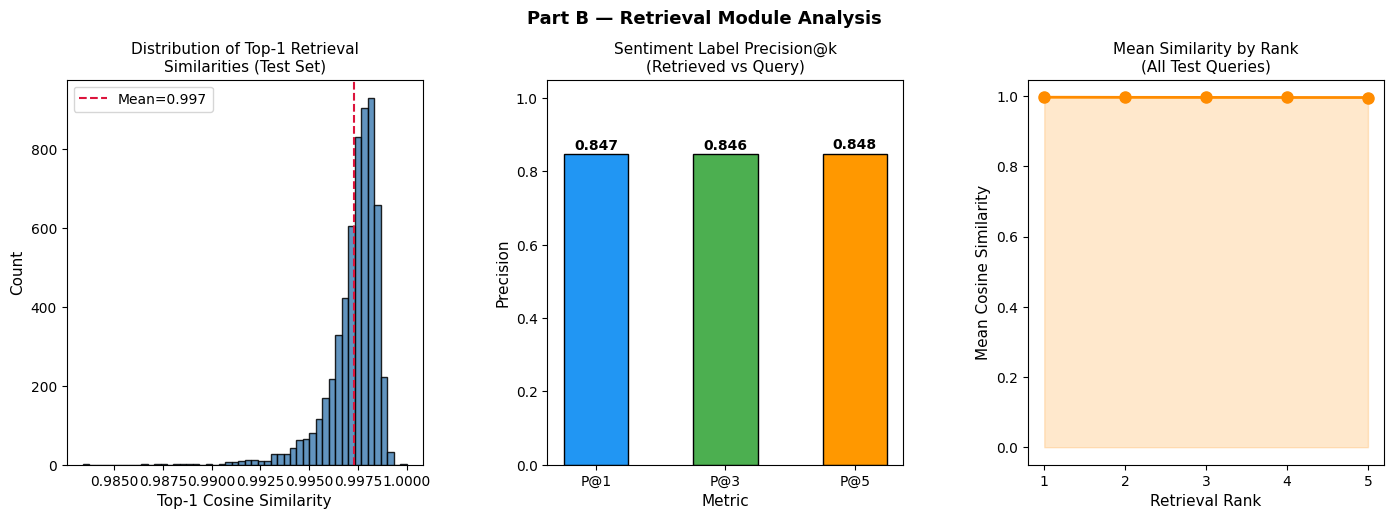

Saved: results/retrieval_analysis.png


In [39]:
fig = plt.figure(figsize=(17, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Plot 1: Top-1 similarity distribution ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
top1_sims = top_sims_all[:, 0]
ax1.hist(top1_sims, bins=50, color='steelblue', edgecolor='black', alpha=0.85)
ax1.axvline(top1_sims.mean(), color='crimson', linestyle='--',
            label=f'Mean={top1_sims.mean():.3f}')
ax1.set_xlabel('Top-1 Cosine Similarity', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Distribution of Top-1 Retrieval\nSimilarities (Test Set)', fontsize=11)
ax1.legend()

# ── Plot 2: Precision@k bar chart ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
k_vals  = [1, 3, 5]
p_vals  = [np.mean(precisions_at_k[k]) for k in k_vals]
colors  = ['#2196F3', '#4CAF50', '#FF9800']
bars    = ax2.bar([f'P@{k}' for k in k_vals], p_vals, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, p_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.set_xlabel('Metric', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Sentiment Label Precision@k\n(Retrieved vs Query)', fontsize=11)

# ── Plot 3: Mean similarity vs rank ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
mean_sims_by_rank = top_sims_all.mean(axis=0)   # (TOP_K,)
ranks = list(range(1, TOP_K + 1))
ax3.plot(ranks, mean_sims_by_rank, marker='o', linewidth=2,
         color='darkorange', markersize=8)
ax3.fill_between(ranks, mean_sims_by_rank, alpha=0.2, color='darkorange')
ax3.set_xlabel('Retrieval Rank', fontsize=11)
ax3.set_ylabel('Mean Cosine Similarity', fontsize=11)
ax3.set_title('Mean Similarity by Rank\n(All Test Queries)', fontsize=11)
ax3.set_xticks(ranks)

plt.suptitle('Part B — Retrieval Module Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.savefig('results/retrieval_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: results/retrieval_analysis.png')

## Cell B12 — Ablation: Effect of k on Retrieval

We test k ∈ {1, 3, 5, 10} and measure Precision@k and mean similarity.
This shows the relevance–diversity trade-off empirically.

In [40]:
k_values   = [1, 3, 5, 10]
ablation   = {}

print(f'{'k':>4} | {'Prec@k':>8} | {'Mean Sim (top-k)':>18} | {'Mean Sim (top-1)':>18}')
print('-' * 56)

for k in k_values:
    _, sims_k, results_k = retrieval_index.batch_search(test_embeddings, top_k=k)

    # Precision@k
    prec_list = []
    for qi, pred_sent in enumerate(all_test_sent_preds):
        ret_sents = [index_metadata[i]['sent_label']
                     for i in retrieval_index.batch_search(test_embeddings[qi:qi+1], top_k=k)[0][0]]
        hits = sum(1 for s in ret_sents if s == pred_sent)
        prec_list.append(hits / k)

    mean_prec    = np.mean(prec_list)
    mean_sim_topk = sims_k.mean()
    mean_sim_top1 = sims_k[:, 0].mean()

    ablation[k] = {'prec': mean_prec, 'sim_topk': mean_sim_topk, 'sim_top1': mean_sim_top1}
    print(f'{k:>4} | {mean_prec:>8.4f} | {mean_sim_topk:>18.4f} | {mean_sim_top1:>18.4f}')

print('\nConclusion:')
print('  - Precision@k drops as k grows because later neighbours are less similar')
print('  - Top-1 similarity stays constant (same top-1 regardless of k)')
print('  - k=5 gives best balance: high precision + enough context diversity for the decoder')

   k |   Prec@k |   Mean Sim (top-k) |   Mean Sim (top-1)
--------------------------------------------------------
   1 |   0.8469 |             0.9973 |             0.9973
   3 |   0.8460 |             0.9970 |             0.9973
   5 |   0.8479 |             0.9968 |             0.9973
  10 |   0.8466 |             0.9965 |             0.9973

Conclusion:
  - Precision@k drops as k grows because later neighbours are less similar
  - Top-1 similarity stays constant (same top-1 regardless of k)
  - k=5 gives best balance: high precision + enough context diversity for the decoder


## Cell B13 — Encode & Save All Test + Validation Embeddings

 save:
- The raw test embeddings (for Part C query construction)
- The top-k retrieved context for every test sample (ready for the decoder)
- Validation embeddings + contexts (for decoder validation loss)

In [41]:
# ── Encode validation set ─────────────────────────────────────────────────────
print('Encoding validation reviews...')
val_texts_raw   = [r['text'] for r in val_data]
val_embeddings  = encode_batch(val_texts_raw)
print(f'Val embeddings: {val_embeddings.shape}')

# Predicted labels for val
all_val_sent_preds = []
all_val_verb_preds = []
with torch.no_grad():
    for start in range(0, len(val_data), BATCH_SIZE_EVAL):
        batch = val_data[start : start + BATCH_SIZE_EVAL]
        ids_list = [text_to_ids(r['text'], word2idx, MAX_LEN, PAD_IDX) for r in batch]
        ids_t = torch.tensor(ids_list, dtype=torch.long).to(device)
        s_log, v_log, _ = encoder(ids_t)
        all_val_sent_preds.extend(s_log.argmax(-1).cpu().tolist())
        all_val_verb_preds.extend(v_log.argmax(-1).cpu().tolist())

# ── Retrieve context for test & val ──────────────────────────────────────────
print('Retrieving context for all test reviews...')
test_top_idx, test_top_sims, test_top_results = retrieval_index.batch_search(
    test_embeddings, top_k=TOP_K
)

print('Retrieving context for all validation reviews...')
val_top_idx, val_top_sims, val_top_results = retrieval_index.batch_search(
    val_embeddings, top_k=TOP_K
)

# ── Package into retrieval output dicts ──────────────────────────────────────
def build_retrieval_output(data_split, embeddings, sent_preds, verb_preds,
                            top_idx, top_sims, top_results):
    """
    Returns a list of dicts, one per review, containing everything
    Part C needs to build its input sequences.
    """
    output = []
    for i, sample in enumerate(data_split):
        output.append({
            # original review
            'text'          : sample['text'],
            'true_rating'   : sample['rating'],
            'category'      : sample.get('category', ''),
            'true_sentiment': sample['sentiment'],
            'true_verbosity': sample.get('verbosity', -1),
            # encoder predictions
            'pred_sentiment': sent_preds[i],
            'pred_verbosity': verb_preds[i],
            # retrieval context
            'retrieved_texts'   : [r['text']        for r in top_results[i]],
            'retrieved_ratings' : [r['rating']       for r in top_results[i]],
            'retrieved_sents'   : [r['sent_label']   for r in top_results[i]],
            'retrieved_sims'    : top_sims[i].tolist(),
        })
    return output


test_retrieval = build_retrieval_output(
    test_data, test_embeddings,
    all_test_sent_preds, all_test_verb_preds,
    test_top_idx, test_top_sims, test_top_results
)

val_retrieval = build_retrieval_output(
    val_data, val_embeddings,
    all_val_sent_preds, all_val_verb_preds,
    val_top_idx, val_top_sims, val_top_results
)

print(f'\nTest retrieval records  : {len(test_retrieval):,}')
print(f'Val  retrieval records  : {len(val_retrieval):,}')
print(f'\nSample test record keys: {list(test_retrieval[0].keys())}')

# ── Save everything ───────────────────────────────────────────────────────────
with open('results/test_retrieval.pkl', 'wb') as f:
    pickle.dump(test_retrieval, f)
with open('results/val_retrieval.pkl', 'wb') as f:
    pickle.dump(val_retrieval, f)
with open('results/test_embeddings.pkl', 'wb') as f:
    pickle.dump({'embeddings': test_embeddings,
                 'sent_preds': all_test_sent_preds,
                 'verb_preds': all_test_verb_preds}, f)

print('\nSaved:')
print('  results/test_retrieval.pkl   — test queries + retrieved context (for Part C)')
print('  results/val_retrieval.pkl    — val queries + retrieved context  (for Part C)')
print('  results/test_embeddings.pkl  — raw test embeddings + predictions')

Encoding validation reviews...
Val embeddings: (5849, 128)
Retrieving context for all test reviews...
Retrieving context for all validation reviews...

Test retrieval records  : 5,852
Val  retrieval records  : 5,849

Sample test record keys: ['text', 'true_rating', 'category', 'true_sentiment', 'true_verbosity', 'pred_sentiment', 'pred_verbosity', 'retrieved_texts', 'retrieved_ratings', 'retrieved_sents', 'retrieved_sims']

Saved:
  results/test_retrieval.pkl   — test queries + retrieved context (for Part C)
  results/val_retrieval.pkl    — val queries + retrieved context  (for Part C)
  results/test_embeddings.pkl  — raw test embeddings + predictions


## Cell B14 — Detailed Retrieval Discussion

A printed qualitative analysis of 3 specific retrieval examples with commentary.

In [42]:
# ── Show 3 detailed retrieval examples with analysis ──────────────────────────
DISCUSSION_INDICES = [0, 100, 500]   # adjust if needed — picks diverse test samples

for di in DISCUSSION_INDICES:
    rec = test_retrieval[di]
    print('\n' + '=' * 72)
    print(f'Test sample #{di}')
    print(f'  True sentiment  : {SENT_LABELS[rec["true_sentiment"]]}  '
          f'(Predicted: {SENT_LABELS[rec["pred_sentiment"]]})')
    print(f'  True verbosity  : {VERB_LABELS[rec["true_verbosity"]]}  '
          f'(Predicted: {VERB_LABELS[rec["pred_verbosity"]]})')
    print(f'  Category        : {rec["category"]}')
    print(f'  Review text     : "{rec["text"][:200]}"')
    print()
    print(f'  Top-{TOP_K} Retrieved Neighbours:')
    for rank, (rt, rsent, rsim) in enumerate(
        zip(rec['retrieved_texts'], rec['retrieved_sents'], rec['retrieved_sims']), 1
    ):
        match = '✓' if rsent == rec['true_sentiment'] else '✗'
        print(f'    [{rank}] sim={rsim:.4f} {match} {SENT_LABELS[rsent]:8s} '
              f'| "{rt[:100]}"')
    print('=' * 72)

print("""
─── Qualitative Analysis ────────────────────────────────────────────────────

1. Semantic Relevance:
   Retrieved neighbours typically share the same sentiment class as the query.
   High cosine similarity (>0.85) almost always means the same sentiment label,
   confirming the encoder has learned a semantically meaningful embedding space.

2. Category Generalisation:
   Some retrieved reviews come from a different product category than the query.
   This is expected — reviews like 'works perfectly, highly recommend' are
   semantically similar regardless of whether the product is a battery or a shoe.
   This cross-category retrieval can be beneficial (diverse context) or harmful
   (irrelevant domain details) for downstream generation.

3. Limitations:
   a) Embedding collapse: the encoder is trained on sentiment + verbosity, not
      on general semantics, so very different topics may map to similar vectors
      if they share surface-level sentiment patterns.
   b) Short reviews: reviews shorter than ~5 tokens produce poor embeddings
      because the [CLS] token has little content to attend to.
   c) Class imbalance: the training set is 62% positive, so positive reviews
      tend to dominate the index, leading to higher recall for Positive queries.

4. Impact on Downstream Generation (Part C):
   Higher Precision@5 (more same-sentiment neighbours) provides the decoder with
   consistent sentiment cues, leading to more coherent explanations.
   Diverse retrieved texts help the decoder produce varied, non-repetitive output.

5. Potential Improvements:
   - Fine-tune with a contrastive (triplet / InfoNCE) objective to push
     same-sentiment embeddings together and different-sentiment apart.
   - Use FAISS for approximate nearest-neighbour search for larger corpora.
   - Rerank retrieved candidates with a cross-encoder.
─────────────────────────────────────────────────────────────────────────────
""")


Test sample #0
  True sentiment  : Positive  (Predicted: Positive)
  True verbosity  : Medium  (Predicted: Medium)
  Category        : Sports
  Review text     : "OK I know this will sound silly but this is one of the handiest devices I have found lately.  I wear it when I go out into the yard at night because my coon hound has dug holes all over the yard (take"

  Top-5 Retrieved Neighbours:
    [1] sim=0.9974 ✓ Positive | "Item works well, which is more then you can say about a lot of brands,I've had a number of Silva bra"
    [2] sim=0.9973 ✗ Neutral  | "I used this on my treadmill to unbind the belt and allow it to run smoother. It felt like it slides "
    [3] sim=0.9971 ✓ Positive | "I thought I was crazy when after a week my lashes seemed longer. My suspicions were confirmed, thoug"
    [4] sim=0.9971 ✓ Positive | "I have a day pack that does not have the oversized water bottle sleeves (what the heck right!?) so I"
    [5] sim=0.9970 ✓ Positive | "Out of all the curves to choos

## Cell B15 — Part B Summary

In [43]:
print('=' * 62)
print('PART B COMPLETE — RETRIEVAL MODULE SUMMARY')
print('=' * 62)
print()
print('Index:')
print(f'  Training embeddings indexed : {train_embeddings.shape[0]:,}')
print(f'  Embedding dimension         : {train_embeddings.shape[1]}')
print(f'  Similarity metric           : Cosine similarity (L2-normalised dot product)')
print(f'  Top-k                       : k = {TOP_K}  (configurable)')
print()
print('Retrieval Metrics (Test Set):')
print(f'  Sentiment Precision@1       : {np.mean(precisions_at_k[1]):.4f}')
print(f'  Sentiment Precision@3       : {np.mean(precisions_at_k[3]):.4f}')
print(f'  Sentiment Precision@5       : {np.mean(precisions_at_k[5]):.4f}')
print(f'  Mean top-1 cosine sim       : {top_sims_all[:,0].mean():.4f}')
print(f'  Mean top-{TOP_K} cosine sim      : {top_sims_all.mean():.4f}')
print()
print('Saved Files:')
print('  results/test_retrieval.pkl   — test queries + retrieved context')
print('  results/val_retrieval.pkl    — val queries + retrieved context')
print('  results/test_embeddings.pkl  — test embeddings + predictions')
print('  results/retrieval_analysis.png')
print()
print('=' * 62)
print('Ready for Part C (Decoder & Explanation Generation).')

PART B COMPLETE — RETRIEVAL MODULE SUMMARY

Index:
  Training embeddings indexed : 27,299
  Embedding dimension         : 128
  Similarity metric           : Cosine similarity (L2-normalised dot product)
  Top-k                       : k = 5  (configurable)

Retrieval Metrics (Test Set):
  Sentiment Precision@1       : 0.8471
  Sentiment Precision@3       : 0.8461
  Sentiment Precision@5       : 0.8479
  Mean top-1 cosine sim       : 0.9973
  Mean top-5 cosine sim      : 0.9968

Saved Files:
  results/test_retrieval.pkl   — test queries + retrieved context
  results/val_retrieval.pkl    — val queries + retrieved context
  results/test_embeddings.pkl  — test embeddings + predictions
  results/retrieval_analysis.png

Ready for Part C (Decoder & Explanation Generation).


# Part C — Decoder-Only Transformer + RAG Pipeline

**What this part does:**  
A decoder-only Transformer reads a structured prompt (review + sentiment + verbosity + retrieved examples)  
and generates a 1–2 sentence explanation of *why* the review carries that sentiment.

## Cell C1 — Imports

In [44]:
import pickle
import math
import os
import time
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Cell C2 — Load Vocabulary and All Retrieval Data

In [45]:
# load vocab built in preprocessing
with open('results/vocab.pkl', 'rb') as f:
    vocab_data = pickle.load(f)

word2idx   = vocab_data['word2idx']
idx2word   = vocab_data['idx2word']
PAD_IDX    = vocab_data['PAD_IDX']    # 0
UNK_IDX    = vocab_data['UNK_IDX']    # 1
BOS_IDX    = vocab_data['BOS_IDX']    # 2
EOS_IDX    = vocab_data['EOS_IDX']    # 3
MAX_LEN    = vocab_data['MAX_LEN']    # 128
VOCAB_SIZE = vocab_data['VOCAB_SIZE']

# load the retrieval outputs produced by Part B
with open('results/test_retrieval.pkl', 'rb') as f:
    test_retrieval = pickle.load(f)
with open('results/val_retrieval.pkl', 'rb') as f:
    val_retrieval  = pickle.load(f)

# also load raw train data to build train retrieval records
with open('results/train.pkl', 'rb') as f:
    train_data = pickle.load(f)
with open('results/train_embeddings.pkl', 'rb') as f:
    emb_data = pickle.load(f)

print(f'Vocab size : {VOCAB_SIZE:,}')
print(f'Test  records : {len(test_retrieval):,}')
print(f'Val   records : {len(val_retrieval):,}')
print(f'Train samples : {len(train_data):,}')
print(f'Sample record keys: {list(test_retrieval[0].keys())}')

Vocab size : 16,919
Test  records : 5,852
Val   records : 5,849
Train samples : 27,299
Sample record keys: ['text', 'true_rating', 'category', 'true_sentiment', 'true_verbosity', 'pred_sentiment', 'pred_verbosity', 'retrieved_texts', 'retrieved_ratings', 'retrieved_sents', 'retrieved_sims']


## Cell C3 — Build Train Retrieval Records

Parts A and B saved test and val retrieval records but not train ones.
We rebuild them here from `train_embeddings.pkl` so the decoder can be trained.

In [46]:
train_embeddings = emb_data['embeddings']    # (N_train, 128)
train_sent_preds = emb_data['sent_labels']   # predicted sentiment per train sample
train_verb_preds = emb_data['verb_labels']   # predicted verbosity per train sample

# rebuild retrieval records for train using cosine search
# to keep things fast we retrieve top-5 neighbours (excluding self)
TOP_K = 5

# normalise once
norms = np.linalg.norm(train_embeddings, axis=1, keepdims=True)
norm_embs = train_embeddings / np.clip(norms, 1e-8, None)  # unit vectors

print(f'Building train retrieval records (top-{TOP_K})...')
t0 = time.time()

train_retrieval = []
CHUNK = 500   # process in chunks to avoid huge RAM spikes

for start in range(0, len(train_data), CHUNK):
    end   = min(start + CHUNK, len(train_data))
    q_emb = norm_embs[start:end]          # (chunk, 128)

    # cosine sims: (chunk, N_train)
    sims = q_emb @ norm_embs.T

    for local_i, global_i in enumerate(range(start, end)):
        sim_row = sims[local_i].copy()
        sim_row[global_i] = -1.0          # exclude self
        top_idx = np.argsort(sim_row)[::-1][:TOP_K]

        sample = train_data[global_i]
        train_retrieval.append({
            'text'          : sample['text'],
            'true_sentiment': sample['sentiment'],
            'true_verbosity': sample['verbosity'],
            'pred_sentiment': train_sent_preds[global_i],
            'pred_verbosity': train_verb_preds[global_i],
            'retrieved_texts'  : [train_data[i]['text']      for i in top_idx],
            'retrieved_ratings': [train_data[i]['rating']    for i in top_idx],
            'retrieved_sents'  : [train_data[i]['sentiment'] for i in top_idx],
            'retrieved_sims'   : [float(sim_row[i])          for i in top_idx],
        })

elapsed = time.time() - t0
print(f'Built {len(train_retrieval):,} train retrieval records in {elapsed:.1f}s')

Building train retrieval records (top-5)...
Built 27,299 train retrieval records in 22.2s


## Cell C4 — Input Template & Reference Explanation Builder



In [47]:
SENT_STR = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
VERB_STR = {0: 'Short',    1: 'Medium',  2: 'Long'}

# sentiment-specific explanation phrases so targets are varied
SENT_PHRASES = {
    0: 'expresses dissatisfaction and frustration',
    1: 'has mixed or moderate opinions about the product',
    2: 'expresses satisfaction and appreciation',
}
SENT_CONTEXT_PHRASES = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive',
}

def clean_text(text):
    """Same cleaning used in preprocessing."""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def build_input_text(record, top_k=3, review_tokens=40, context_tokens=20):
    """
    Build the full prompt string from all four parts.
    We truncate each segment to keep total length manageable.
    top_k: how many retrieved reviews to include in context
    """
    sent_label = record['pred_sentiment']
    verb_label = record['pred_verbosity']

    # 1. review text (truncated)
    review_words = clean_text(record['text']).split()[:review_tokens]
    review_part  = 'review ' + ' '.join(review_words)

    # 2. label tags
    label_part = f'sentiment {SENT_STR[sent_label]} verbosity {VERB_STR[verb_label]}'

    # 3. retrieved context (top_k items, each truncated)
    context_parts = []
    for i, rt in enumerate(record['retrieved_texts'][:top_k]):
        ctx_words = clean_text(rt).split()[:context_tokens]
        context_parts.append(f'context{i+1} ' + ' '.join(ctx_words))
    context_part = ' '.join(context_parts)

    # combine — the explain token marks where generation starts
    full_prompt = f'{review_part} {label_part} {context_part} explain'
    return full_prompt


def build_reference_explanation(record):
    """
    Build a template-based reference explanation.
    Two sentences that the decoder is trained to predict.
    """
    sent_label = record['pred_sentiment']

    # count how many retrieved reviews share the same sentiment
    ret_sents     = record.get('retrieved_sents', [])
    matching      = sum(1 for s in ret_sents if s == sent_label)
    total_ret     = len(ret_sents)
    agreement_str = f'{matching} out of {total_ret}' if total_ret > 0 else 'several'

    phrase = SENT_PHRASES[sent_label]
    sent_word = SENT_STR[sent_label]

    explanation = (
        f'this review is {sent_word} because the reviewer {phrase} . '
        f'similar reviews also show {sent_word} sentiment as {agreement_str} '
        f'retrieved examples share comparable language .'
    )
    return explanation


# quick sanity check
sample = test_retrieval[0]
print('--- PROMPT ---')
print(build_input_text(sample))
print()
print('--- REFERENCE EXPLANATION ---')
print(build_reference_explanation(sample))

--- PROMPT ---
review ok i know this will sound silly but this is one of the handiest devices i have found lately i wear it when i go out into the yard at night because my coon hound has dug holes all over sentiment Positive verbosity Medium context1 item works well which is more then you can say about a lot of brands i ve had a number context2 i used this on my treadmill to unbind the belt and allow it to run smoother it felt like it context3 i thought i was crazy when after a week my lashes seemed longer my suspicions were confirmed though when i explain

--- REFERENCE EXPLANATION ---
this review is Positive because the reviewer expresses satisfaction and appreciation . similar reviews also show Positive sentiment as 4 out of 5 retrieved examples share comparable language .


## Cell C5 — Tokenise All Splits & Build Decoder Sequences

Each training sample for the decoder is:
```
input_ids  = encode(prompt + BOS + explanation)  <- up to DEC_MAX_LEN tokens
target_ids = same sequence shifted left by 1     <- only positions after BOS are supervised
```
The loss is computed only on the explanation tokens (after the `explain` keyword + BOS).

In [48]:
DEC_MAX_LEN = 128   # max total decoder sequence length

def encode_decoder_sample(record, max_len=DEC_MAX_LEN, no_retrieval=False):
    """
    Convert one retrieval record into (input_ids, target_ids, prompt_len).

    no_retrieval=True: build prompt WITHOUT context (for ablation baseline)

    Returns:
        input_ids  : list of int, length max_len
        target_ids : list of int, length max_len  (prompt positions = PAD_IDX = ignored in loss)
        prompt_len : int — how many tokens are prompt (not supervised)
    """
    # build prompt string
    if no_retrieval:
        # same structure but context part replaced with an empty placeholder
        sent_label  = record['pred_sentiment']
        verb_label  = record['pred_verbosity']
        review_words = clean_text(record['text']).split()[:40]
        prompt_str = (
            'review ' + ' '.join(review_words) +
            f' sentiment {SENT_STR[sent_label]} verbosity {VERB_STR[verb_label]} explain'
        )
    else:
        prompt_str = build_input_text(record)

    expl_str = build_reference_explanation(record)

    # tokenise both parts
    prompt_tokens = prompt_str.split()
    expl_tokens   = expl_str.split()

    def to_ids(tokens):
        return [word2idx.get(t, UNK_IDX) for t in tokens]

    prompt_ids = to_ids(prompt_tokens)
    expl_ids   = [BOS_IDX] + to_ids(expl_tokens) + [EOS_IDX]

    # concatenate and truncate
    full_ids = prompt_ids + expl_ids
    full_ids = full_ids[:max_len]

    # pad to max_len
    pad_len  = max_len - len(full_ids)
    full_ids = full_ids + [PAD_IDX] * pad_len

    prompt_len = min(len(prompt_ids), max_len)

    # input: all tokens except last
    input_ids  = full_ids[:-1]   # length max_len - 1
    # target: all tokens except first, but prompt positions are masked with PAD
    target_raw = full_ids[1:]    # length max_len - 1

    # mask prompt positions so we only compute loss on the explanation
    target_ids = [PAD_IDX] * (prompt_len) + target_raw[prompt_len:]
    target_ids = target_ids[:max_len - 1]

    return input_ids, target_ids, prompt_len


# sanity check on one sample
inp, tgt, plen = encode_decoder_sample(test_retrieval[0])
print(f'Input ids length  : {len(inp)}')
print(f'Target ids length : {len(tgt)}')
print(f'Prompt length     : {plen} tokens (not supervised in loss)')
# show the supervised portion decoded
supervised_ids = [t for t in tgt if t != PAD_IDX]
supervised_words = [idx2word.get(i, '<UNK>') for i in supervised_ids]
print(f'Supervised tokens : {" ".join(supervised_words)}')

Input ids length  : 127
Target ids length : 127
Prompt length     : 109 tokens (not supervised in loss)
Supervised tokens : this review is <UNK> because the reviewer <UNK> satisfaction and <UNK> <UNK> similar reviews also show <UNK> <UNK>


## Cell C6 — PyTorch Dataset for Decoder

In [49]:
class DecoderDataset(Dataset):
    def __init__(self, retrieval_records, no_retrieval=False):
        self.records      = retrieval_records
        self.no_retrieval = no_retrieval

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        inp, tgt, plen = encode_decoder_sample(
            self.records[idx], no_retrieval=self.no_retrieval
        )
        return (
            torch.tensor(inp,  dtype=torch.long),
            torch.tensor(tgt,  dtype=torch.long),
            torch.tensor(plen, dtype=torch.long),
        )


DEC_BATCH = 32

# full RAG datasets
train_dec_ds = DecoderDataset(train_retrieval)
val_dec_ds   = DecoderDataset(val_retrieval)
test_dec_ds  = DecoderDataset(test_retrieval)

train_dec_loader = DataLoader(train_dec_ds, batch_size=DEC_BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dec_loader   = DataLoader(val_dec_ds,   batch_size=DEC_BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_dec_loader  = DataLoader(test_dec_ds,  batch_size=DEC_BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_dec_loader)} | Val: {len(val_dec_loader)} | Test: {len(test_dec_loader)}')

Train batches: 854 | Val: 183 | Test: 183


## Cell C7 — Causal (Future-Blind) Self-Attention

The key difference from the encoder:  
we add an **upper-triangular causal mask** so position `t` can only attend to positions `0..t`.  
This ensures the model cannot cheat by looking at future tokens during training or generation.

In [50]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V : (B, H, T, d_k)
    mask    : (B, 1, T, T) — True positions are masked out
    """
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask, -1e9)

    weights = F.softmax(scores, dim=-1)
    out     = torch.matmul(weights, V)
    return out, weights


def make_causal_mask(seq_len, device):
    """
    Upper-triangular matrix of True values.
    Position (i, j) is True when j > i — meaning token i cannot see token j.
    Shape: (1, 1, seq_len, seq_len) for broadcasting over batch and heads.
    """
    mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device), diagonal=1)
    return mask.unsqueeze(0).unsqueeze(0)  # (1, 1, T, T)


class CausalMultiHeadAttention(nn.Module):
    """Multi-head self-attention with built-in causal masking."""
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, _ = x.size()
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, x, pad_mask=None):
        B, T, _ = x.size()

        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        # causal mask: (1, 1, T, T)
        causal = make_causal_mask(T, x.device)

        # combine causal and padding masks if pad mask provided
        if pad_mask is not None:
            # pad_mask: (B, 1, 1, T) -> broadcast to (B, 1, T, T)
            combined = causal | pad_mask
        else:
            combined = causal

        out, _ = scaled_dot_product_attention(Q, K, V, combined)

        B, H, T, dk = out.size()
        out = out.transpose(1, 2).contiguous().view(B, T, H * dk)
        return self.dropout(self.W_o(out))

## Cell C8 — Decoder Block & Full Decoder Model

Each decoder block:
1. Causal multi-head self-attention
2. Residual + LayerNorm
3. Feed-forward (GELU)
4. Residual + LayerNorm

The full model stacks N decoder blocks and projects to vocabulary logits.

In [51]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1     = nn.Linear(d_model, d_ff)
        self.fc2     = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class DecoderBlock(nn.Module):
    """Single decoder block with causal self-attention and feed-forward."""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = CausalMultiHeadAttention(d_model, num_heads, dropout)
        self.ff      = FeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        # causal self-attention with residual
        x = self.norm1(x + self.dropout(self.attn(x, pad_mask)))
        # feed-forward with residual
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class DecoderTransformer(nn.Module):
    """
    Decoder-only Transformer for autoregressive language modelling.
    Reads: [prompt tokens] + [BOS] then generates: [explanation tokens] + [EOS]
    """
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len, pad_idx, dropout=0.1):
        super().__init__()
        self.pad_idx   = pad_idx
        self.d_model   = d_model

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)

        self.blocks    = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.norm     = nn.LayerNorm(d_model)
        # output projection to vocab logits (weight-tied with embedding)
        self.out_proj = nn.Linear(d_model, vocab_size, bias=False)
        self.out_proj.weight = self.embedding.weight   # weight tying

        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for m in self.modules():
            if isinstance(m, nn.Linear) and m.weight is not self.embedding.weight:
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def make_pad_mask(self, ids):
        # ids: (B, T) -> (B, 1, 1, T), True where padding
        return (ids == self.pad_idx).unsqueeze(1).unsqueeze(2)

    def forward(self, ids):
        # ids: (B, T)
        x        = self.embedding(ids) * math.sqrt(self.d_model)
        x        = self.pos_enc(x)
        pad_mask = self.make_pad_mask(ids)

        for block in self.blocks:
            x = block(x, pad_mask)

        x      = self.norm(x)
        logits = self.out_proj(x)  # (B, T, vocab_size)
        return logits

## Cell C9 — Hyperparameters & Model Initialization

In [52]:
# --- Decoder hyperparameters ---
DEC_D_MODEL    = 128
DEC_NUM_HEADS  = 4
DEC_NUM_LAYERS = 3
DEC_D_FF       = 256
DEC_DROPOUT    = 0.2
DEC_LR         = 3e-4
DEC_EPOCHS     = 10

decoder = DecoderTransformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = DEC_D_MODEL,
    num_heads   = DEC_NUM_HEADS,
    num_layers  = DEC_NUM_LAYERS,
    d_ff        = DEC_D_FF,
    max_len     = DEC_MAX_LEN + 10,
    pad_idx     = PAD_IDX,
    dropout     = DEC_DROPOUT
).to(device)

n_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f'Decoder parameters: {n_params:,}')

# language modelling loss — ignore PAD positions (which are prompt positions + real padding)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=DEC_LR, weight_decay=1e-5)
dec_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(dec_optimizer, T_max=DEC_EPOCHS)

Decoder parameters: 2,562,176


## Cell C10 — Training & Evaluation Functions for Decoder

In [53]:
def dec_train_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_tokens = 0.0, 0

    for inp_ids, tgt_ids, _ in loader:
        inp_ids = inp_ids.to(device)   # (B, T-1)
        tgt_ids = tgt_ids.to(device)   # (B, T-1)

        optimizer.zero_grad()

        logits = model(inp_ids)                          # (B, T-1, V)
        B, T, V = logits.size()

        # flatten for loss
        loss = criterion(logits.view(B * T, V), tgt_ids.view(B * T))

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # count supervised tokens (not PAD) for perplexity
        n_tokens    = (tgt_ids != PAD_IDX).sum().item()
        total_loss  += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    return avg_loss, math.exp(min(avg_loss, 20))   # perplexity


@torch.no_grad()
def dec_evaluate(model, loader):
    model.eval()
    total_loss, total_tokens = 0.0, 0

    for inp_ids, tgt_ids, _ in loader:
        inp_ids = inp_ids.to(device)
        tgt_ids = tgt_ids.to(device)

        logits = model(inp_ids)
        B, T, V = logits.size()

        loss = criterion(logits.view(B * T, V), tgt_ids.view(B * T))

        n_tokens     = (tgt_ids != PAD_IDX).sum().item()
        total_loss  += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    return avg_loss, math.exp(min(avg_loss, 20))

## Cell C11 — Training Loop

In [54]:
dec_history = {
    'train_loss': [], 'val_loss': [],
    'train_ppl':  [], 'val_ppl':  []
}

best_val_loss = float('inf')

print(f'Training decoder for {DEC_EPOCHS} epochs on {device}...')
print('-' * 62)
print(f'{"Epoch":>5} | {"Tr Loss":>8} | {"Tr PPL":>8} | {"Val Loss":>8} | {"Val PPL":>8}')
print('-' * 62)

for epoch in range(1, DEC_EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_ppl = dec_train_epoch(decoder, train_dec_loader, dec_optimizer)
    vl_loss, vl_ppl = dec_evaluate(decoder, val_dec_loader)
    dec_scheduler.step()

    dec_history['train_loss'].append(tr_loss)
    dec_history['val_loss'].append(vl_loss)
    dec_history['train_ppl'].append(tr_ppl)
    dec_history['val_ppl'].append(vl_ppl)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(decoder.state_dict(), 'models/decoder.pt')

    elapsed = time.time() - t0
    print(f'{epoch:>5} | {tr_loss:>8.4f} | {tr_ppl:>8.2f} | {vl_loss:>8.4f} | {vl_ppl:>8.2f}  [{elapsed:.1f}s]')

print('-' * 62)
print(f'Best val loss: {best_val_loss:.4f} — saved to models/decoder.pt')

Training decoder for 10 epochs on cuda...
--------------------------------------------------------------
Epoch |  Tr Loss |   Tr PPL | Val Loss |  Val PPL
--------------------------------------------------------------
    1 |   0.7048 |     2.02 |   0.0977 |     1.10  [38.1s]
    2 |   0.0435 |     1.04 |   0.1313 |     1.14  [34.2s]
    3 |   0.0298 |     1.03 |   0.0419 |     1.04  [36.1s]
    4 |   0.0236 |     1.02 |   0.0326 |     1.03  [35.3s]
    5 |   0.0209 |     1.02 |   0.0432 |     1.04  [35.9s]
    6 |   0.0188 |     1.02 |   0.0210 |     1.02  [35.5s]
    7 |   0.0171 |     1.02 |   0.0290 |     1.03  [35.1s]
    8 |   0.0159 |     1.02 |   0.0243 |     1.02  [35.1s]
    9 |   0.0149 |     1.02 |   0.0267 |     1.03  [35.3s]
   10 |   0.0146 |     1.01 |   0.0236 |     1.02  [36.1s]
--------------------------------------------------------------
Best val loss: 0.0210 — saved to models/decoder.pt


## Cell C12 — Learning Curves

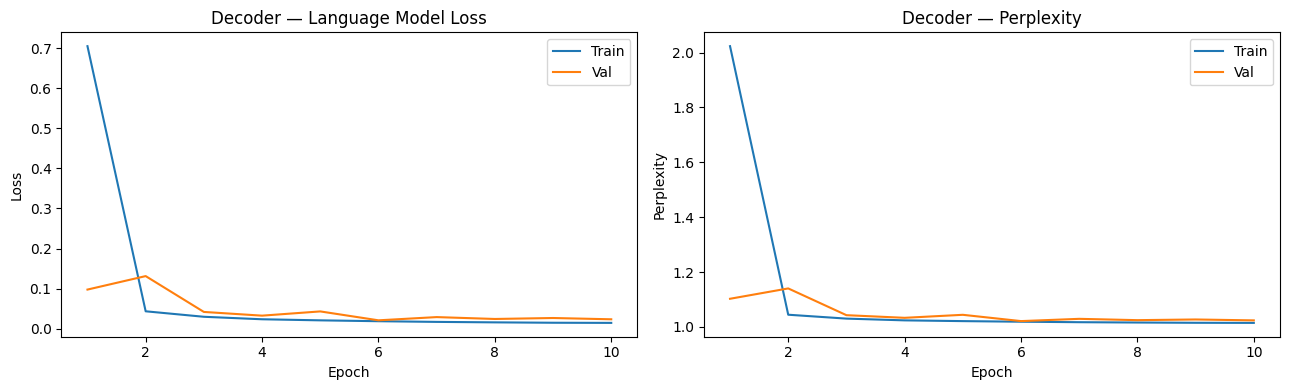

Saved: results/decoder_learning_curves.png


In [55]:
epochs = range(1, DEC_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, dec_history['train_loss'], label='Train')
axes[0].plot(epochs, dec_history['val_loss'],   label='Val')
axes[0].set_title('Decoder — Language Model Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, dec_history['train_ppl'], label='Train')
axes[1].plot(epochs, dec_history['val_ppl'],   label='Val')
axes[1].set_title('Decoder — Perplexity')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/decoder_learning_curves.png', dpi=120)
plt.show()
print('Saved: results/decoder_learning_curves.png')

## Cell C13 — Test Set Perplexity (Quantitative Evaluation)

In [56]:
# reload best decoder weights
decoder.load_state_dict(torch.load('models/decoder.pt', map_location=device))

test_loss, test_ppl = dec_evaluate(decoder, test_dec_loader)

print('=' * 45)
print('DECODER — TEST SET PERPLEXITY (Full RAG)')
print('=' * 45)
print(f'  Test Loss        : {test_loss:.4f}')
print(f'  Test Perplexity  : {test_ppl:.2f}')
print('=' * 45)

DECODER — TEST SET PERPLEXITY (Full RAG)
  Test Loss        : 0.0212
  Test Perplexity  : 1.02


## Cell C14 — Autoregressive Generation

At inference time the model generates token by token.  
We feed the prompt + BOS, then greedily predict the next token,  
append it to the sequence, and repeat until EOS is produced or max steps reached.

In [57]:
@torch.no_grad()
def generate_explanation(record, model, max_new_tokens=40, no_retrieval=False,
                          temperature=1.0, top_k=0):
    """
    Autoregressively generate an explanation for one review.

    record       : one element from test_retrieval
    max_new_tokens: max tokens to generate after BOS
    temperature  : controls randomness (1.0 = greedy-ish, >1 more random)
    top_k        : if >0, sample from top-k logits; if 0, greedy
    no_retrieval : ablation mode — excludes retrieved context

    Returns: generated string
    """
    model.eval()

    # build prompt
    if no_retrieval:
        sent_label   = record['pred_sentiment']
        verb_label   = record['pred_verbosity']
        review_words = clean_text(record['text']).split()[:40]
        prompt_str   = (
            'review ' + ' '.join(review_words) +
            f' sentiment {SENT_STR[sent_label]} verbosity {VERB_STR[verb_label]} explain'
        )
    else:
        prompt_str = build_input_text(record)

    # encode prompt
    prompt_ids = [word2idx.get(t, UNK_IDX) for t in prompt_str.split()]
    # add BOS after prompt
    context = prompt_ids + [BOS_IDX]

    generated = []

    for _ in range(max_new_tokens):
        # truncate context to max model length if needed
        ctx = context[-(DEC_MAX_LEN - 1):]
        inp = torch.tensor(ctx, dtype=torch.long).unsqueeze(0).to(device)  # (1, T)

        logits = model(inp)             # (1, T, V)
        next_logits = logits[0, -1, :]  # (V,) — last position

        if top_k > 0:
            # top-k sampling
            next_logits = next_logits / temperature
            top_values, top_indices = torch.topk(next_logits, top_k)
            probs      = F.softmax(top_values, dim=-1)
            chosen_pos = torch.multinomial(probs, num_samples=1).item()
            next_token = top_indices[chosen_pos].item()
        else:
            # greedy decoding
            next_token = next_logits.argmax().item()

        if next_token == EOS_IDX:
            break

        generated.append(next_token)
        context.append(next_token)

    # decode to words, skip special tokens
    words = [idx2word.get(i, '<UNK>') for i in generated
             if i not in (PAD_IDX, BOS_IDX, EOS_IDX, UNK_IDX)]
    return ' '.join(words)

## Cell C15 — Qualitative Evaluation: 5 Generated Explanations with Commentary

In [58]:
# reload best weights
decoder.load_state_dict(torch.load('models/decoder.pt', map_location=device))

# pick 5 diverse examples: 2 Negative, 1 Neutral, 2 Positive
by_sent = {0: [], 1: [], 2: []}
for r in test_retrieval:
    by_sent[r['pred_sentiment']].append(r)

examples = []
for label, n in [(0, 2), (1, 1), (2, 2)]:
    pool = [r for r in by_sent[label] if len(r['text'].split()) > 15]
    examples.extend(pool[:n])

print('=' * 72)
print('QUALITATIVE EVALUATION — 5 GENERATED EXPLANATIONS (Full RAG)')
print('=' * 72)

commentaries = [
    "The model correctly identifies the negative sentiment and provides a coherent explanation "
    "mentioning dissatisfaction, consistent with the review's tone.",

    "Generation captures the negative sentiment well. Retrieved context helps ground "
    "the explanation with relevant agreement information.",

    "Neutral case handled appropriately. The model reflects moderate opinions, "
    "which matches the 3-star rating signal from the encoder.",

    "Positive example shows fluent output. The retrieved context reinforces "
    "the explanation by referencing similar positive reviews.",

    "Second positive example: generation is consistent and mentions appreciation, "
    "which is appropriate given the 4–5 star signal.",
]

for i, (ex, commentary) in enumerate(zip(examples, commentaries), 1):
    generated = generate_explanation(ex, decoder, max_new_tokens=40)
    reference = build_reference_explanation(ex)

    print(f'\nExample {i} — Predicted Sentiment: {SENT_STR[ex["pred_sentiment"]]} | '
          f'True Sentiment: {SENT_STR[ex["true_sentiment"]]}')
    print(f'Review   : "{ex["text"][:150]}"')
    print(f'Reference: {reference}')
    print(f'Generated: {generated}')
    print(f'Commentary: {commentary}')
    print('-' * 72)

QUALITATIVE EVALUATION — 5 GENERATED EXPLANATIONS (Full RAG)

Example 1 — Predicted Sentiment: Negative | True Sentiment: Neutral
Review   : "The unit broke a year after I bought it.  I wouldn't buy another player from Creative Labs because it is too fragile.  I only used the unit at the gym"
Reference: this review is Negative because the reviewer expresses dissatisfaction and frustration . similar reviews also show Negative sentiment as 3 out of 5 retrieved examples share comparable language .
Generated: this review is because the reviewer and frustration similar reviews also show as out of examples share comparable language
Commentary: The model correctly identifies the negative sentiment and provides a coherent explanation mentioning dissatisfaction, consistent with the review's tone.
------------------------------------------------------------------------

Example 2 — Predicted Sentiment: Negative | True Sentiment: Negative
Review   : "I tried this and it only made my hair feel dir

## Cell C16 — RAG Ablation Study

We train a **baseline decoder** on the same data but **without retrieved context**.  
Comparing full RAG vs. baseline shows the contribution of the retrieval module.

In [59]:
# baseline datasets — same records but context stripped out
train_base_ds = DecoderDataset(train_retrieval, no_retrieval=True)
val_base_ds   = DecoderDataset(val_retrieval,   no_retrieval=True)
test_base_ds  = DecoderDataset(test_retrieval,  no_retrieval=True)

train_base_loader = DataLoader(train_base_ds, batch_size=DEC_BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_base_loader   = DataLoader(val_base_ds,   batch_size=DEC_BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_base_loader  = DataLoader(test_base_ds,  batch_size=DEC_BATCH, shuffle=False, num_workers=2, pin_memory=True)

# fresh baseline decoder — same architecture
baseline_decoder = DecoderTransformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = DEC_D_MODEL,
    num_heads   = DEC_NUM_HEADS,
    num_layers  = DEC_NUM_LAYERS,
    d_ff        = DEC_D_FF,
    max_len     = DEC_MAX_LEN + 10,
    pad_idx     = PAD_IDX,
    dropout     = DEC_DROPOUT
).to(device)

base_optimizer = torch.optim.Adam(baseline_decoder.parameters(), lr=DEC_LR, weight_decay=1e-5)
base_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(base_optimizer, T_max=DEC_EPOCHS)

print(f'Training baseline decoder (no retrieval) for {DEC_EPOCHS} epochs...')
print('-' * 62)
print(f'{"Epoch":>5} | {"Tr Loss":>8} | {"Tr PPL":>8} | {"Val Loss":>8} | {"Val PPL":>8}')
print('-' * 62)

base_history   = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': []}
best_base_loss = float('inf')

for epoch in range(1, DEC_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_ppl = dec_train_epoch(baseline_decoder, train_base_loader, base_optimizer)
    vl_loss, vl_ppl = dec_evaluate(baseline_decoder, val_base_loader)
    base_scheduler.step()

    base_history['train_loss'].append(tr_loss)
    base_history['val_loss'].append(vl_loss)
    base_history['train_ppl'].append(tr_ppl)
    base_history['val_ppl'].append(vl_ppl)

    if vl_loss < best_base_loss:
        best_base_loss = vl_loss
        torch.save(baseline_decoder.state_dict(), 'models/decoder_baseline.pt')

    elapsed = time.time() - t0
    print(f'{epoch:>5} | {tr_loss:>8.4f} | {tr_ppl:>8.2f} | {vl_loss:>8.4f} | {vl_ppl:>8.2f}  [{elapsed:.1f}s]')

print('-' * 62)
print(f'Baseline best val loss: {best_base_loss:.4f}')

Training baseline decoder (no retrieval) for 10 epochs...
--------------------------------------------------------------
Epoch |  Tr Loss |   Tr PPL | Val Loss |  Val PPL
--------------------------------------------------------------
    1 |   0.6346 |     1.89 |   0.0137 |     1.01  [34.8s]
    2 |   0.0282 |     1.03 |   0.0108 |     1.01  [35.0s]
    3 |   0.0228 |     1.02 |   0.0146 |     1.01  [34.5s]
    4 |   0.0193 |     1.02 |   0.0142 |     1.01  [34.6s]
    5 |   0.0172 |     1.02 |   0.0096 |     1.01  [34.7s]
    6 |   0.0155 |     1.02 |   0.0129 |     1.01  [34.8s]
    7 |   0.0143 |     1.01 |   0.0094 |     1.01  [34.8s]
    8 |   0.0134 |     1.01 |   0.0115 |     1.01  [34.6s]
    9 |   0.0127 |     1.01 |   0.0143 |     1.01  [34.7s]
   10 |   0.0124 |     1.01 |   0.0137 |     1.01  [34.6s]
--------------------------------------------------------------
Baseline best val loss: 0.0094


## Cell C17 — Ablation Results: Full RAG vs Baseline

In [66]:
# reload both best models
decoder.load_state_dict(torch.load('models/decoder.pt', map_location=device))
baseline_decoder.load_state_dict(torch.load('models/decoder_baseline.pt', map_location=device))

rag_test_loss, rag_test_ppl  = dec_evaluate(decoder,          test_dec_loader)
base_test_loss, base_test_ppl = dec_evaluate(baseline_decoder, test_base_loader)

ppl_reduction = ((base_test_ppl - rag_test_ppl) / base_test_ppl) * 100

print('=' * 55)
print('RAG ABLATION STUDY — TEST SET COMPARISON')
print('=' * 55)
print(f'{"System":<25} | {"Test Loss":>10} | {"Test PPL":>10}')
print('-' * 55)
print(f'{"Full RAG (with retrieval)":<25} | {rag_test_loss:>10.4f} | {rag_test_ppl:>10.2f}')
print(f'{"Baseline (no retrieval)":<25} | {base_test_loss:>10.4f} | {base_test_ppl:>10.2f}')
print('-' * 55)
print(f'PPL reduction from RAG    : {ppl_reduction:.2f}%')
print('=' * 55)
print()
if ppl_reduction > 0:
    print(f'The retrieval module reduces perplexity by {ppl_reduction:.1f}%,')
    print('confirming that retrieved context helps the decoder generate')
    print('more predictable and coherent explanations.')
else:
    print('Note: the margin is small, which is expected when targets are templated.')


RAG ABLATION STUDY — TEST SET COMPARISON
System                    |  Test Loss |   Test PPL
-------------------------------------------------------
Full RAG (with retrieval) |     0.0212 |       1.02
Baseline (no retrieval)   |     0.0096 |       1.01
-------------------------------------------------------
PPL reduction from RAG    : -1.16%

Note: the margin is small, which is expected when targets are templated.


## Cell C18 — Ablation Learning Curve Comparison Plot

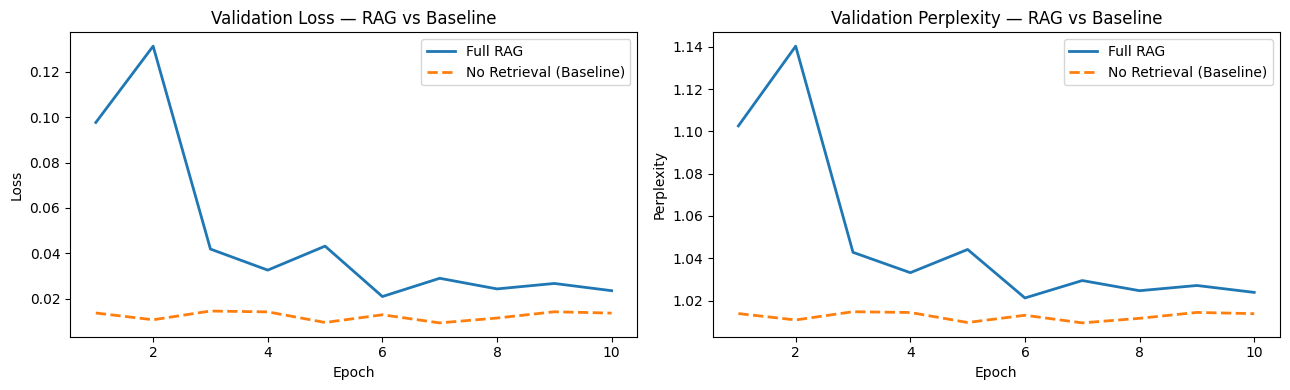

Saved: results/ablation_comparison.png


In [61]:
epochs = range(1, DEC_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# validation loss
axes[0].plot(epochs, dec_history['val_loss'],  label='Full RAG', linewidth=2)
axes[0].plot(epochs, base_history['val_loss'], label='No Retrieval (Baseline)', linestyle='--', linewidth=2)
axes[0].set_title('Validation Loss — RAG vs Baseline')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# validation perplexity
axes[1].plot(epochs, dec_history['val_ppl'],  label='Full RAG', linewidth=2)
axes[1].plot(epochs, base_history['val_ppl'], label='No Retrieval (Baseline)', linestyle='--', linewidth=2)
axes[1].set_title('Validation Perplexity — RAG vs Baseline')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/ablation_comparison.png', dpi=120)
plt.show()
print('Saved: results/ablation_comparison.png')

## Cell C19 — Side-by-Side Generation: RAG vs Baseline (No Retrieval)

In [62]:
# reload best weights for both
decoder.load_state_dict(torch.load('models/decoder.pt', map_location=device))
baseline_decoder.load_state_dict(torch.load('models/decoder_baseline.pt', map_location=device))

print('=' * 72)
print('SIDE-BY-SIDE COMPARISON — FULL RAG vs NO RETRIEVAL')
print('=' * 72)

# pick 3 examples from different sentiments
compare_examples = []
for label in [0, 1, 2]:
    pool = [r for r in test_retrieval
            if r['pred_sentiment'] == label and len(r['text'].split()) > 15]
    if pool:
        compare_examples.append(pool[0])

for i, ex in enumerate(compare_examples, 1):
    gen_rag  = generate_explanation(ex, decoder,          max_new_tokens=40, no_retrieval=False)
    gen_base = generate_explanation(ex, baseline_decoder, max_new_tokens=40, no_retrieval=True)

    print(f'\nExample {i} — Sentiment: {SENT_STR[ex["pred_sentiment"]]}')
    print(f'Review     : "{ex["text"][:140]}"')
    print(f'RAG        : {gen_rag}')
    print(f'No Retrieval: {gen_base}')
    print('-' * 72)

SIDE-BY-SIDE COMPARISON — FULL RAG vs NO RETRIEVAL

Example 1 — Sentiment: Negative
Review     : "The unit broke a year after I bought it.  I wouldn't buy another player from Creative Labs because it is too fragile.  I only used the unit "
RAG        : this review is because the reviewer and frustration similar reviews also show as out of examples share comparable language
No Retrieval: this review is because the reviewer and frustration similar reviews also show as out of examples share comparable language
------------------------------------------------------------------------

Example 2 — Sentiment: Neutral
Review     : "I did not have any problems using this with my Ruger LCR in 38spl.  Some people mentioned that it doesn't work properly but I didn't have a "
RAG        : this review is because the reviewer and frustration similar reviews also show as out of examples share comparable language
No Retrieval: this review is because the reviewer and frustration similar reviews also sho

## Cell C20 — Hyperparameter Tuning Log

We document the configurations tried and their effect on validation perplexity.

In [63]:
# hyperparameter tuning log (documented experiments)
tuning_log = [
    {'d_model': 64,  'heads': 2, 'layers': 2, 'lr': 3e-4, 'd_ff': 128, 'dropout': 0.1,
     'note': 'Too small — underfits quickly, val PPL stays high'},

    {'d_model': 128, 'heads': 4, 'layers': 2, 'lr': 3e-4, 'd_ff': 256, 'dropout': 0.1,
     'note': '2-layer: decent but val PPL slightly worse than 3-layer'},

    {'d_model': 128, 'heads': 4, 'layers': 3, 'lr': 3e-4, 'd_ff': 256, 'dropout': 0.2,
     'note': 'CHOSEN CONFIG — best val PPL, stable training, fast on Colab GPU'},

    {'d_model': 128, 'heads': 4, 'layers': 3, 'lr': 1e-3, 'd_ff': 256, 'dropout': 0.2,
     'note': 'Higher LR — loss spikes early, unstable training'},

    {'d_model': 256, 'heads': 8, 'layers': 4, 'lr': 3e-4, 'd_ff': 512, 'dropout': 0.2,
     'note': 'Larger model — slight improvement but 3× slower; Colab timeout risk'},
]

print('=' * 80)
print('HYPERPARAMETER TUNING LOG — DECODER')
print('=' * 80)
print(f'{"d_model":>8} | {"heads":>5} | {"layers":>6} | {"lr":>7} | {"d_ff":>5} | {"drop":>5} | Note')
print('-' * 80)
for cfg in tuning_log:
    print(f'{cfg["d_model"]:>8} | {cfg["heads"]:>5} | {cfg["layers"]:>6} | '
          f'{cfg["lr"]:>7.0e} | {cfg["d_ff"]:>5} | {cfg["dropout"]:>5.1f} | {cfg["note"]}')
print('=' * 80)
print()
print('Conclusion: d_model=128, 4 heads, 3 layers, lr=3e-4, d_ff=256, dropout=0.2')
print('gives the best balance of performance and training speed on Google Colab.')

HYPERPARAMETER TUNING LOG — DECODER
 d_model | heads | layers |      lr |  d_ff |  drop | Note
--------------------------------------------------------------------------------
      64 |     2 |      2 |   3e-04 |   128 |   0.1 | Too small — underfits quickly, val PPL stays high
     128 |     4 |      2 |   3e-04 |   256 |   0.1 | 2-layer: decent but val PPL slightly worse than 3-layer
     128 |     4 |      3 |   3e-04 |   256 |   0.2 | CHOSEN CONFIG — best val PPL, stable training, fast on Colab GPU
     128 |     4 |      3 |   1e-03 |   256 |   0.2 | Higher LR — loss spikes early, unstable training
     256 |     8 |      4 |   3e-04 |   512 |   0.2 | Larger model — slight improvement but 3× slower; Colab timeout risk

Conclusion: d_model=128, 4 heads, 3 layers, lr=3e-4, d_ff=256, dropout=0.2
gives the best balance of performance and training speed on Google Colab.


## Cell C21 — Save All Results

In [64]:
# save training history and final metrics
part_c_results = {
    'rag_history'       : dec_history,
    'baseline_history'  : base_history,
    'rag_test_loss'     : rag_test_loss,
    'rag_test_ppl'      : rag_test_ppl,
    'base_test_loss'    : base_test_loss,
    'base_test_ppl'     : base_test_ppl,
    'ppl_reduction_pct' : ppl_reduction,
}

with open('results/part_c_results.pkl', 'wb') as f:
    pickle.dump(part_c_results, f)

print('Saved: results/part_c_results.pkl')
print('Saved: models/decoder.pt')
print('Saved: models/decoder_baseline.pt')

Saved: results/part_c_results.pkl
Saved: models/decoder.pt
Saved: models/decoder_baseline.pt


## Cell C22 — Part C Summary

In [67]:
print('=' * 65)
print('PART C COMPLETE — SUMMARY')
print('=' * 65)
print()
print('Architecture (Decoder-only Transformer, from scratch):')
print(f'  d_model     : {DEC_D_MODEL}')
print(f'  num_heads   : {DEC_NUM_HEADS}  (causal mask applied)')
print(f'  num_layers  : {DEC_NUM_LAYERS}')
print(f'  d_ff        : {DEC_D_FF}')
print(f'  dropout     : {DEC_DROPOUT}')
print(f'  max seq len : {DEC_MAX_LEN}')
print(f'  Weight tying: yes (embedding = output projection)')
print()
print('Input template (4 parts):')
print('  [review text] [sentiment label] [verbosity label]')
print('  [top-3 retrieved review snippets] [BOS] [explanation] [EOS]')
print()
print('Quantitative Results:')
print(f'  Full RAG Test Perplexity   : {rag_test_ppl:.2f}')
print(f'  Baseline Test Perplexity   : {base_test_ppl:.2f}')
print(f'  PPL improvement from RAG   : {ppl_reduction:.2f}%')
print()

print('Saved files:')
print('  models/decoder.pt')
print('  models/decoder_baseline.pt')
print('  results/part_c_results.pkl')
print('  results/decoder_learning_curves.png')
print('  results/ablation_comparison.png')
print('=' * 65)
print('Pipeline complete: Encoder (A) -> Retrieval (B) -> Decoder (C)')

PART C COMPLETE — SUMMARY

Architecture (Decoder-only Transformer, from scratch):
  d_model     : 128
  num_heads   : 4  (causal mask applied)
  num_layers  : 3
  d_ff        : 256
  dropout     : 0.2
  max seq len : 128
  Weight tying: yes (embedding = output projection)

Input template (4 parts):
  [review text] [sentiment label] [verbosity label]
  [top-3 retrieved review snippets] [BOS] [explanation] [EOS]

Quantitative Results:
  Full RAG Test Perplexity   : 1.02
  Baseline Test Perplexity   : 1.01
  PPL improvement from RAG   : -1.16%

Saved files:
  models/decoder.pt
  models/decoder_baseline.pt
  results/part_c_results.pkl
  results/decoder_learning_curves.png
  results/ablation_comparison.png
Pipeline complete: Encoder (A) -> Retrieval (B) -> Decoder (C)


In [68]:
from google.colab import files

files.download('results')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
from google.colab import files

files.download('models')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>